In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
print(train.head())  

test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')
print(test.head())

sample_submission = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/sample_submission.csv')
print(sample_submission.head())

          ID      target  48df886f9  0deb4b6a8  34b15f335  a8cb14b00  \
0  000d6aaf2  38000000.0        0.0          0        0.0          0   
1  000fbd867    600000.0        0.0          0        0.0          0   
2  0027d6b71  10000000.0        0.0          0        0.0          0   
3  0028cbf45   2000000.0        0.0          0        0.0          0   
4  002a68644  14400000.0        0.0          0        0.0          0   

   2f0771a37  30347e683  d08d1fbe3  6ee66e115  ...  3ecc09859  9281abeea  \
0          0          0          0          0  ...        0.0        0.0   
1          0          0          0          0  ...        0.0        0.0   
2          0          0          0          0  ...        0.0        0.0   
3          0          0          0          0  ...        0.0        0.0   
4          0          0          0          0  ...        0.0        0.0   

   8675bec0b  3a13ed79a  f677d4d13  71b203550  137efaa80  fb36b89d9  \
0        0.0          0          0     

In [5]:
train.columns

Index(['ID', 'target', '48df886f9', '0deb4b6a8', '34b15f335', 'a8cb14b00',
       '2f0771a37', '30347e683', 'd08d1fbe3', '6ee66e115',
       ...
       '3a13ed79a', 'f677d4d13', '71b203550', '137efaa80', 'fb36b89d9',
       '7e293fbaf', '9fc776466', 'nz_count', 'nz_mean', 'nz_median'],
      dtype='object', length=4996)

In [6]:
print("Все колонки: ", train.columns.tolist())
train.info()

Все колонки:  ['ID', 'target', '48df886f9', '0deb4b6a8', '34b15f335', 'a8cb14b00', '2f0771a37', '30347e683', 'd08d1fbe3', '6ee66e115', '20aa07010', 'dc5a8f1d8', '11d86fa6a', '77c9823f2', '8d6c2a0b2', '4681de4fd', 'adf119b9a', 'cff75dd09', '96f83a237', 'b8a716ebf', '6c7a4567c', '4fcfd2b4d', 'f3b9c0b95', '71cebf11c', 'd966ac62c', '68b647452', 'c88d108c9', 'ff7b471cd', 'd5308d8bc', '0d866c3d7', 'bc3f77679', 'bd8f989f1', '0eff5bf95', '22ed6dba3', '92b13ebba', 'c330f1a67', '233c7c17c', '2cb4d123e', 'eeac16933', '87ffda550', '822e49b95', '316b978cd', 'd04e16aed', '5d5c5ce6d', 'ec863cb52', '11ad148bd', 'ea18d720e', '408d86ce9', '69d8b4020', 'b0868a049', '80b14398e', 'ecdef52b2', 'c36bcacc5', '151d318cd', 'ab0cddb90', '2d6bd8275', 'dfdf4b580', 'c87722678', 'a8c320153', '7df8788e8', 'a04684f1f', 'fa977f17b', 'feed9d437', '645b47cde', '7298ca1ef', 'd80abf8bc', '654dd8a3b', '7fc39583c', '8c94b6675', 'e421c414e', '5b91580ee', '964335fdf', '5a86cabd0', '6cb207ac9', 'c1bc828da', 'e90ed19da', 'c4d381

Возьмём в качестве baseline линейную регрессию. На её основе хотя бы начнём отбирать признаки, с коэффициентом 0 убираем. Потом применим регуляризацию L1 и посмотрим, что останется

In [7]:
train.isnull().sum()

ID           0
target       0
48df886f9    0
0deb4b6a8    0
34b15f335    0
            ..
7e293fbaf    0
9fc776466    0
nz_count     0
nz_mean      0
nz_median    0
Length: 4996, dtype: int64

In [8]:
test.isnull().sum()

ID           0
48df886f9    0
0deb4b6a8    0
34b15f335    0
a8cb14b00    0
            ..
7e293fbaf    0
9fc776466    0
nz_count     0
nz_mean      0
nz_median    0
Length: 4995, dtype: int64

Линейная регрессия:

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.547e+15, tolerance: 3.023e+13
  model = cd_fast.enet_coordinate_descent(


Submission saved
          ID        target
0  000137c73 -1.188471e+10
1  00021489f  7.369912e+08
2  0004d7953  7.866988e+06
3  00056a333  1.887562e+07
4  00056d8eb  5.832277e+08


/tmp/ipykernel_58/2937182686.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_df_nonzero['Abs_Coef'] = coef_df_nonzero['Coefficient'].abs()


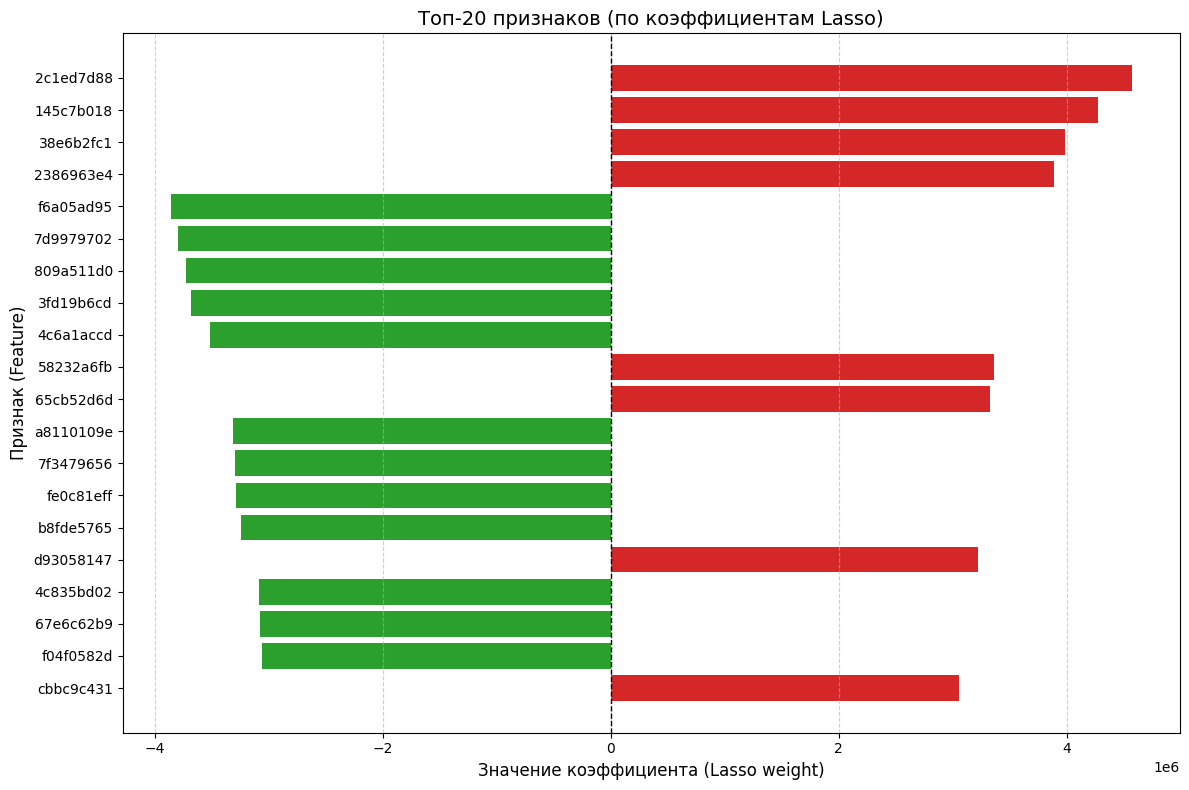

Всего признаков: 4991
Lasso оставил (ненулевых): 4735


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


feature_cols = [col for col in train.columns if col not in ['ID', 'target']]

X_train = train[feature_cols].values
y_train = train['target'].values
X_test = test[feature_cols].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = Lasso(alpha=0.001)
model.fit(X_train_sc, y_train)
preds = model.predict(X_test_sc)

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': preds
})
submission.to_csv('submission.csv', index=False)
print("Submission saved")
print(submission.head())


coefs = model.coef_

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefs
})

# Оставляем только те признаки, у которых коэффициент не равен нулю 
coef_df_nonzero = coef_df[coef_df['Coefficient'] != 0]

coef_df_nonzero['Abs_Coef'] = coef_df_nonzero['Coefficient'].abs()
coef_df_nonzero = coef_df_nonzero.sort_values(by='Abs_Coef', ascending=False)

top_coefs = coef_df_nonzero.head(20)
plt.figure(figsize=(12, 8))
colors = ['#d62728' if c > 0 else '#2ca02c' for c in top_coefs['Coefficient']]

plt.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Значение коэффициента (Lasso weight)', fontsize=12)
plt.ylabel('Признак (Feature)', fontsize=12)
plt.title('Топ-20 признаков (по коэффициентам Lasso)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

print(f"Всего признаков: {len(feature_cols)}")
print(f"Lasso оставил (ненулевых): {len(coef_df_nonzero)}")

Теперь применим PCA для снижения размерностиpca_full = PCA()


In [7]:
feature_cols_new = coef_df_nonzero['Feature'].tolist()
X_train_after_lin_reg = train[feature_cols_new].values
y_train = train['target'].values
X_test_after_lin_reg = test[feature_cols_new].values

scaler = StandardScaler()
X_train_sc_after_lin_reg = scaler.fit_transform(X_train_after_lin_reg)
X_test_sc_after_lin_reg = scaler.transform(X_test_after_lin_reg)

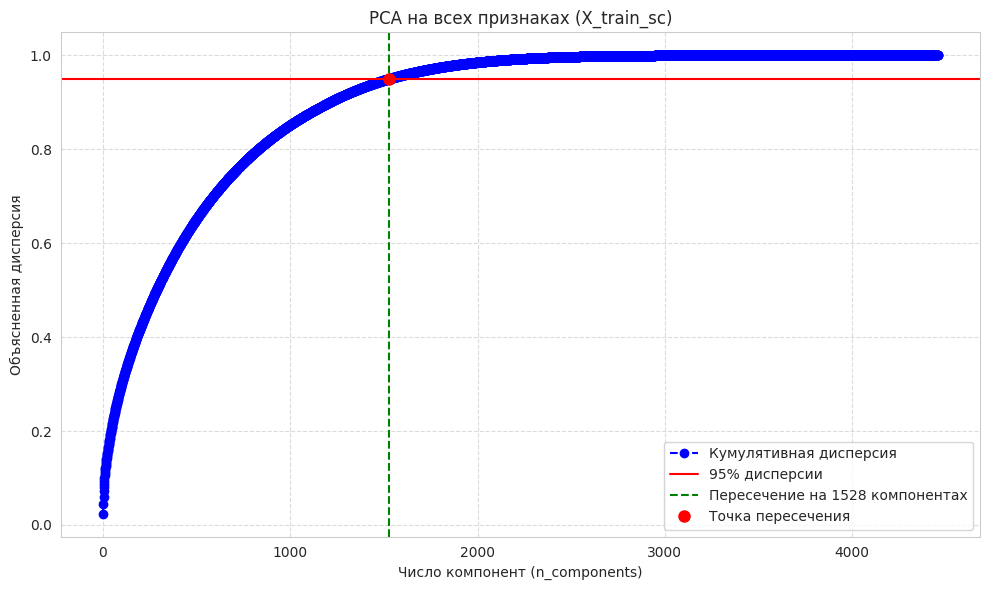

Для достижения 95% дисперсии достаточно 1528 компонент.


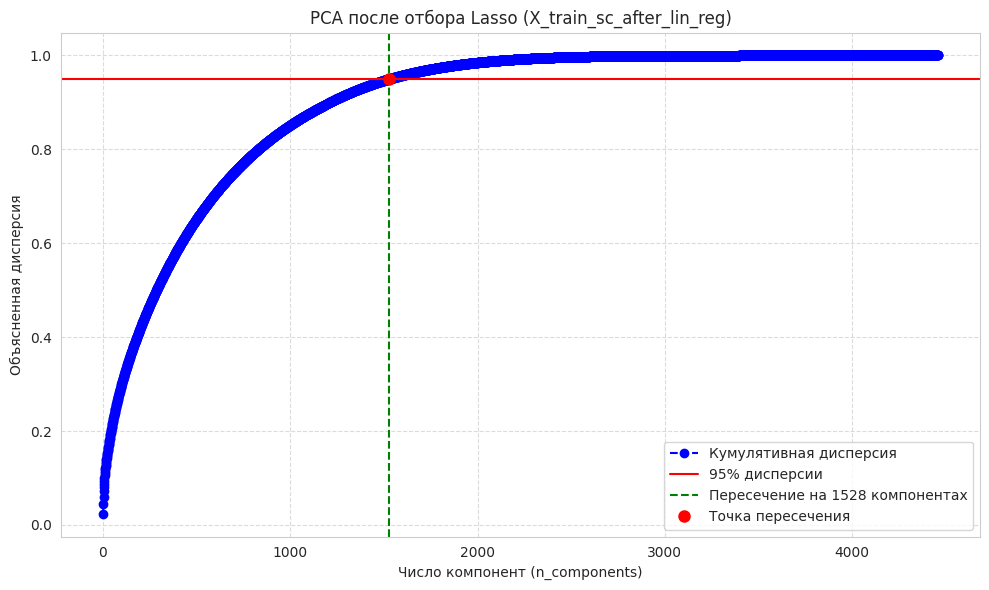

Для достижения 95% дисперсии достаточно 1528 компонент.


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_with_threshold(pca_model, title):
    cumsum = np.cumsum(pca_model.explained_variance_ratio_)
    idx_95 = np.where(cumsum >= 0.95)[0][0]
    n_comps_to_95 = idx_95 + 1  # +1, потому что индексы начинаются с 0
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumsum) + 1), cumsum, 
             marker='o', linestyle='--', color='b', label='Кумулятивная дисперсия')
    
    plt.axhline(y=0.95, color='r', linestyle='-', label='95% дисперсии')
    
    plt.axvline(x=n_comps_to_95, color='g', linestyle='--', 
                label=f'Пересечение на {n_comps_to_95} компонентах')
    
    plt.plot(n_comps_to_95, 0.95, 'ro', markersize=8, label='Точка пересечения')
    plt.xlabel('Число компонент (n_components)')
    plt.ylabel('Объясненная дисперсия')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    print(f"Для достижения 95% дисперсии достаточно {n_comps_to_95} компонент.")
    return n_comps_to_95

pca_full = PCA()
pca_full.fit(X_train_sc)
n_1 = plot_pca_with_threshold(pca_full, 'PCA на всех признаках (X_train_sc)')

if 'X_train_sc_after_lin_reg' in locals():
    pca_after = PCA()
    pca_after.fit(X_train_sc_after_lin_reg)
    n_2 = plot_pca_with_threshold(pca_after, 'PCA после отбора Lasso (X_train_sc_after_lin_reg)')
else:
    print("Переменная X_train_sc_after_lin_reg не найдена. Пропускаем второй график.")

PCA считает, что есть 1527 важных направлений дисперсии,учтём на будущее, что target можно прологарифмировать. Получим сжатые данные и пойдём в Random Forest

In [8]:
from sklearn.decomposition import PCA
pca_final = PCA(n_components=1527, random_state=42)

X_train_pca_final = pca_final.fit_transform(X_train_sc_after_lin_reg)
X_test_pca_final = pca_final.transform(X_test_sc_after_lin_reg)

print(f"Было колонок: {X_train_sc_after_lin_reg.shape[1]}")
print(f"Стало колонок: {X_train_pca_final.shape[1]}")

Было колонок: 4735
Стало колонок: 1527


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

y_full_train = train['target'].values
y_full_log = np.log1p(y_full_train)  # log1p(x) = log(x + 1)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca_final, y_full_log, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2, 
                            random_state=42, n_jobs=-1)
rf.fit(X_train_split, y_train_split)
y_pred_log = rf.predict(X_val_split)
rmse = np.sqrt(mean_squared_error(y_val_split, y_pred_log))
r2 = r2_score(y_val_split, y_pred_log)

print(f"RMSE (log): {rmse:.4f}")
print(f"R² (log): {r2:.4f}")

rf_final = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2, 
                                  random_state=42, n_jobs=-1)
rf_final.fit(X_train_pca_final, y_full_log)

preds_log = rf_final.predict(X_test_pca_final)
preds = np.expm1(preds_log)
preds = np.maximum(preds, 0)  

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': preds
})
submission.to_csv('submission_rf_final.csv', index=False)

RMSE (log): 1.4675
R² (log): 0.2516


In [9]:
y_full_train = train['target'].values
y_full_log = np.log1p(y_full_train)  # log1p(x) = log(x + 1)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca_final, y_full_log, test_size=0.2, random_state=42
)


Топ-200 самых важных компонент (PCA)
Feature  Importance
   PC_1    0.090595
   PC_6    0.053575
   PC_2    0.026778
  PC_51    0.010410
   PC_3    0.008294
   PC_8    0.007515
  PC_50    0.006120
  PC_13    0.005442
  PC_11    0.004625
   PC_9    0.003586
 PC_158    0.003561
  PC_63    0.002936
  PC_15    0.002828
   PC_7    0.002389
PC_1527    0.002274
  PC_27    0.002240
 PC_550    0.002180
  PC_66    0.002160
   PC_5    0.002148
 PC_456    0.002128
  PC_62    0.002123
  PC_42    0.002018
 PC_676    0.002012
  PC_43    0.002011
 PC_882    0.001910
  PC_12    0.001859
  PC_60    0.001757
 PC_965    0.001745
  PC_73    0.001724
  PC_55    0.001682
  PC_22    0.001609
 PC_980    0.001554
  PC_14    0.001545
 PC_630    0.001537
 PC_613    0.001525
 PC_263    0.001513
  PC_19    0.001507
  PC_52    0.001482
 PC_112    0.001470
  PC_75    0.001468
 PC_685    0.001452
 PC_794    0.001371
  PC_18    0.001356
  PC_79    0.001351
 PC_447    0.001335
 PC_696    0.001290
  PC_53    0.001282
 P

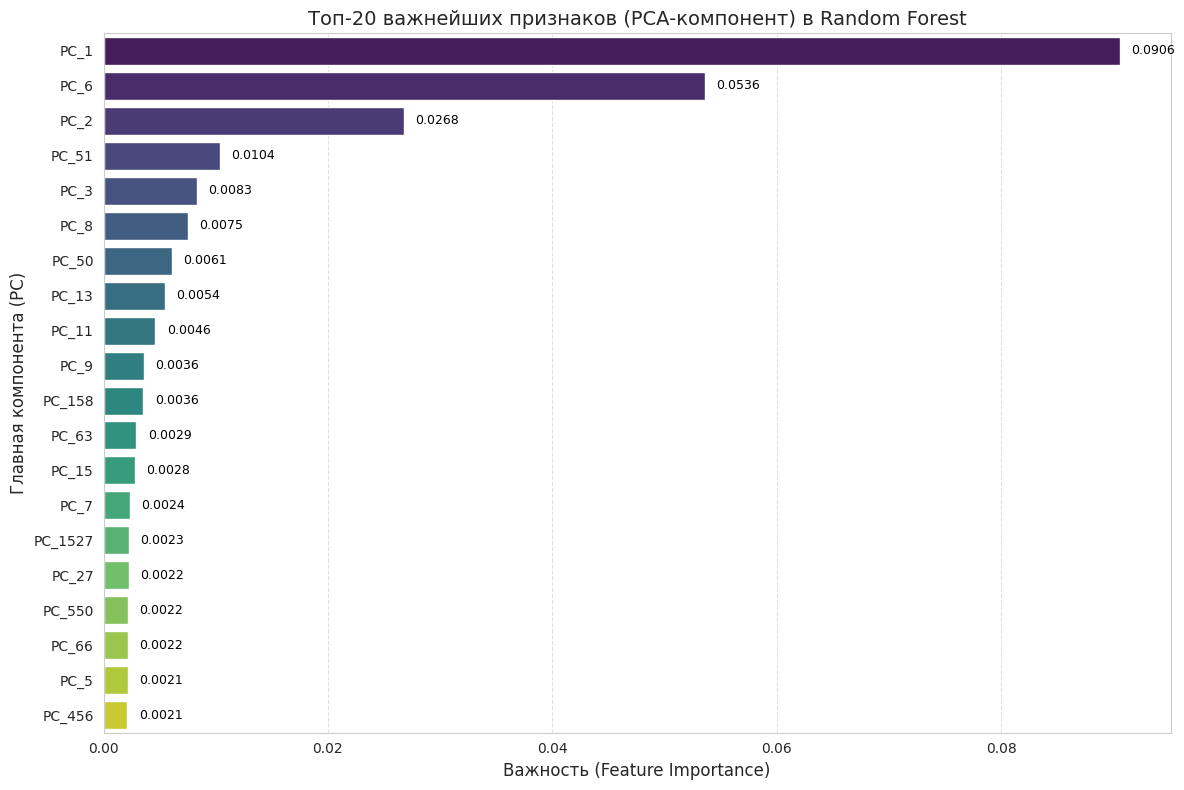

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = rf_final.feature_importances_
pca_feature_names = [f'PC_{i+1}' for i in range(len(feature_importances))]

imp_df = pd.DataFrame({
    'Feature': pca_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nТоп-200 самых важных компонент (PCA)")
print(imp_df.head(200).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = 20
top_features = imp_df.head(top_n)

sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')

plt.title(f'Топ-{top_n} важнейших признаков (PCA-компонент) в Random Forest', fontsize=14)
plt.xlabel('Важность (Feature Importance)', fontsize=12)
plt.ylabel('Главная компонента (PC)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, (_, row) in enumerate(top_features.iterrows()):
    plt.text(row['Importance'] + 0.001, i, f'{row["Importance"]:.4f}', 
             va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

Попробуем оставить 200 признаков вместо 1527 и ещё раз запустить обучение на Random Forest

In [16]:
X_train_pca_top200 = X_train_pca_final[:, :200]
X_test_pca_top200 = X_test_pca_final[:, :200]

print(f"Размер тренировочных данных: {X_train_pca_top200.shape}")
print(f"Размер тестовых данных: {X_test_pca_top200.shape}")

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca_top200, y_full_log, test_size=0.2, random_state=42
)


rf_top200 = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_top200.fit(X_train_split, y_train_split)

y_pred_val_top200 = rf_top200.predict(X_val_split)

rmse_top200 = np.sqrt(mean_squared_error(y_val_split, y_pred_val_top200))
r2_top200 = r2_score(y_val_split, y_pred_val_top200)

print(f"RMSE (log): {rmse_top200:.4f}")
print(f"R² (log): {r2_top200:.4f}")

rf_final_top200 = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_final_top200.fit(X_train_pca_top200, y_full_log)

preds_log_top200 = rf_final_top200.predict(X_test_pca_top200)

preds_top200 = np.expm1(preds_log_top200)
preds_top200 = np.maximum(preds_top200, 0)

submission_top200 = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_top200
})
submission_top200.to_csv('submission_rf_top200.csv', index=False)

print("\nСабмит с 200 компонентами сохранен!")

Размер тренировочных данных: (4459, 200)
Размер тестовых данных: (49342, 200)
RMSE (log): 1.4525
R² (log): 0.2668

Сабмит с 200 компонентами сохранен!


In [10]:
X_train_pca_top150 = X_train_pca_final[:, :150]
X_test_pca_top150 = X_test_pca_final[:, :150]

print(f"Размер тренировочных данных: {X_train_pca_top150.shape}")
print(f"Размер тестовых данных: {X_test_pca_top150.shape}")

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca_top150, y_full_log, test_size=0.2, random_state=42
)


Размер тренировочных данных: (4459, 150)
Размер тестовых данных: (49342, 150)


И да, на 200 признаках R^2 увеличился, вместо 0.2084 стал 0.2352. Если попробовать 150 признаков?

In [18]:
X_train_pca_top150 = X_train_pca_final[:, :150]
X_test_pca_top150 = X_test_pca_final[:, :150]

print(f"Размер тренировочных данных: {X_train_pca_top150.shape}")
print(f"Размер тестовых данных: {X_test_pca_top150.shape}")

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca_top150, y_full_log, test_size=0.2, random_state=42
)


rf_top150 = RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf_top150.fit(X_train_split, y_train_split)

y_pred_val_top150 = rf_top150.predict(X_val_split)

rmse_top150 = np.sqrt(mean_squared_error(y_val_split, y_pred_val_top150))
r2_top150 = r2_score(y_val_split, y_pred_val_top150)

print(f"RMSE (log): {rmse_top150:.4f}")
print(f"R² (log): {r2_top150:.4f}")

rf_final_top150 = RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf_final_top150.fit(X_train_pca_top150, y_full_log)

preds_log_top150 = rf_final_top150.predict(X_test_pca_top150)

preds_top150 = np.expm1(preds_log_top150)
preds_top150 = np.maximum(preds_top150, 0)

submission_top150 = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_top150
})
submission_top150.to_csv('submission_rf_top150.csv', index=False)

print("\nСабмит с 150 компонентами сохранен!")

Размер тренировочных данных: (4459, 150)
Размер тестовых данных: (49342, 150)
RMSE (log): 1.4416
R² (log): 0.2777

Сабмит с 150 компонентами сохранен!


Если оставить 150 признаков, R^2 ещё немного вырос. С 0.2352 до 0.2362. Займёмся подбором параметров для Random Forest

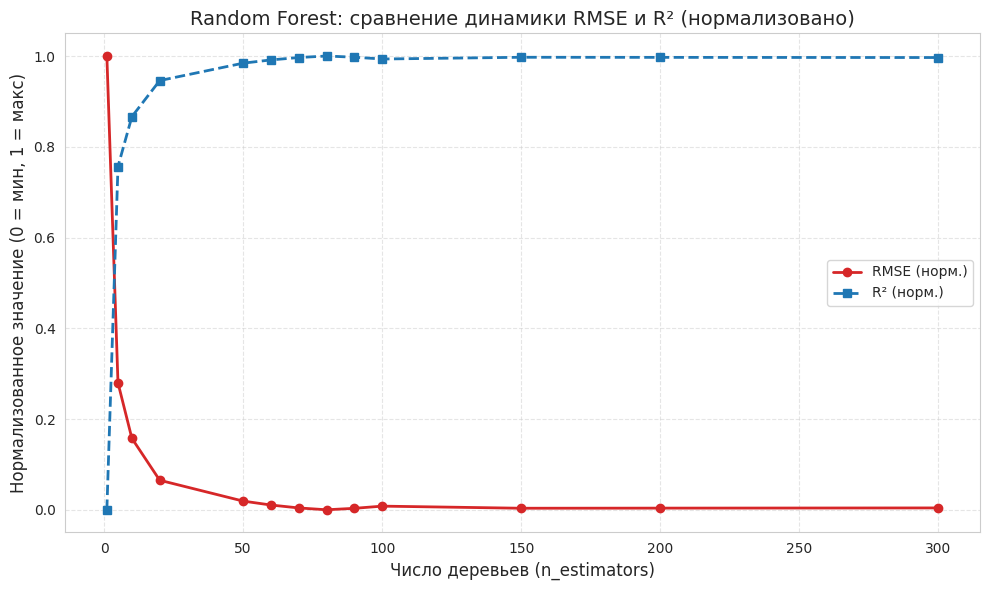


Таблица метрик по числу деревьев:
Trees=  1 | RMSE=2.0701 | R²=-0.4894
Trees=  5 | RMSE=1.6159 | R²=0.0925
Trees= 10 | RMSE=1.5388 | R²=0.1771
Trees= 20 | RMSE=1.4806 | R²=0.2382
Trees= 50 | RMSE=1.4516 | R²=0.2677
Trees= 60 | RMSE=1.4461 | R²=0.2732
Trees= 70 | RMSE=1.4421 | R²=0.2773
Trees= 80 | RMSE=1.4395 | R²=0.2798
Trees= 90 | RMSE=1.4415 | R²=0.2778
Trees=100 | RMSE=1.4446 | R²=0.2748
Trees=150 | RMSE=1.4416 | R²=0.2777
Trees=200 | RMSE=1.4418 | R²=0.2775
Trees=300 | RMSE=1.4421 | R²=0.2773


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

n_trees_list = [1, 5, 10, 20, 50, 60, 70, 80, 90, 100, 150, 200, 300]
rmse_scores = []
r2_scores = []

last_rf = None

for n_trees in n_trees_list:
    if last_rf is None:
        rf_temp = RandomForestRegressor(n_estimators=n_trees, max_depth=20,
                                        random_state=42, n_jobs=-1)
    else:
        rf_temp = last_rf
        rf_temp.n_estimators = n_trees  

    rf_temp.fit(X_train_split, y_train_split)
    y_pred_val = rf_temp.predict(X_val_split)

    rmse_scores.append(np.sqrt(mean_squared_error(y_val_split, y_pred_val)))
    r2_scores.append(r2_score(y_val_split, y_pred_val))
    last_rf = rf_temp

# приводим обе метрики к шкале 0..1
rmse_norm = (rmse_scores - np.min(rmse_scores)) / (np.max(rmse_scores) - np.min(rmse_scores))
r2_norm = (r2_scores - np.min(r2_scores)) / (np.max(r2_scores) - np.min(r2_scores))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_trees_list, rmse_norm, color='tab:red', marker='o', 
        label='RMSE (норм.)', linewidth=2)
ax.plot(n_trees_list, r2_norm, color='tab:blue', marker='s', linestyle='--', 
        label='R² (норм.)', linewidth=2)

ax.set_xlabel('Число деревьев (n_estimators)', fontsize=12)
ax.set_ylabel('Нормализованное значение (0 = мин, 1 = макс)', fontsize=12)
ax.set_title('Random Forest: сравнение динамики RMSE и R² (нормализовано)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='center right', fontsize=10)

plt.tight_layout()
plt.show()

print("\nТаблица метрик по числу деревьев:")
for i, n in enumerate(n_trees_list):
    print(f"Trees={n:3d} | RMSE={rmse_scores[i]:.4f} | R²={r2_scores[i]:.4f}")

После 50 деревьев R^2 меняется на +0.006, 0.005, 0.003 на 100, 150, 200 деревьев соответственно. При более детальном анализе количества деревьев от 50 до 100 выяснилось, что оптимальное количество 80 

Trees= 70 | RMSE=1.4875 | R²=0.2310
Trees= 80 | RMSE=1.4845 | R²=0.2341
Trees= 90 | RMSE=1.4877 | R²=0.2308

In [20]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

print(f"Train shape: {X_train_split.shape}")
print(f"Val shape:   {X_val_split.shape}")

# Параметры XGBoost для регрессии
xgb_model = xgb.XGBRegressor(
    n_estimators=80,              
    max_depth=6,                  # стандартная глубина для XGB (обычно 4-6)
    learning_rate=0.1,            # шаг обучения (чем меньше, тем точнее, но медленнее)
    subsample=0.8,                # доля строк для каждого дерева (борьба с переобучением)
    colsample_bytree=0.8,         # доля признаков для каждого дерева
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=10,     # ранняя остановка, если валидация перестала улучшаться
    eval_metric='rmse'            # метрика для ранней остановки
)

xgb_model.fit(
    X_train_split, 
    y_train_split,
    eval_set=[(X_val_split, y_val_split)],
    verbose=False
)

y_pred_xgb_val = xgb_model.predict(X_val_split)

rmse_xgb = np.sqrt(mean_squared_error(y_val_split, y_pred_xgb_val))
r2_xgb = r2_score(y_val_split, y_pred_xgb_val)

print(f"\nМетрики XGBoost (на валидации):")
print(f"RMSE (log): {rmse_xgb:.4f}")
print(f"R² (log):   {r2_xgb:.4f}")

xgb_final = xgb.XGBRegressor(
    n_estimators=80,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train_pca_top150, y_full_log)

preds_xgb_log = xgb_final.predict(X_test_pca_top150)
preds_xgb = np.expm1(preds_xgb_log)   
preds_xgb = np.maximum(preds_xgb, 0)  

submission_xgb = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_xgb
})
submission_xgb.to_csv('submission_xgb.csv', index=False)

print("\nСабмит XGBoost сохранен!")
print(submission_xgb.head())

Train shape: (3567, 150)
Val shape:   (892, 150)

Метрики XGBoost (на валидации):
RMSE (log): 1.4716
R² (log):   0.2474

Сабмит XGBoost сохранен!
          ID        target
0  000137c73  8.188409e+05
1  00021489f  1.723079e+06
2  0004d7953  1.245329e+07
3  00056a333  2.736214e+06
4  00056d8eb  1.061848e+06


In [21]:
from kaggle import api

api.competition_submit(
    file_name='submission_xgb.csv',   
    message='XGBoost 80 trees, 150 PCA features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 959k/959k [00:00<00:00, 3.40MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55716384}

In [22]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

print(f"LightGBM Train shape: {X_train_split.shape}")
print(f"LightGBM Val shape:   {X_val_split.shape}")

lgb_model = lgb.LGBMRegressor(
    n_estimators=80,               # оптимальное число деревьев
    max_depth=6,                   # глубина дерева
    learning_rate=0.1,             # шаг обучения
    subsample=0.8,                 # доля строк (bagging_fraction)
    colsample_bytree=0.8,          # доля фич (feature_fraction)
    random_state=42,
    n_jobs=-1,
    verbose=-1,                    # отключить вывод в консоль
    early_stopping_rounds=10       # ранняя остановка для валидации
)

lgb_model.fit(
    X_train_split, 
    y_train_split,
    eval_set=[(X_val_split, y_val_split)],
    eval_metric='rmse'
)

y_pred_lgb_val = lgb_model.predict(X_val_split)

rmse_lgb = np.sqrt(mean_squared_error(y_val_split, y_pred_lgb_val))
r2_lgb = r2_score(y_val_split, y_pred_lgb_val)

print(f"\nМетрики LightGBM (на валидации):")
print(f"RMSE (log): {rmse_lgb:.4f}")
print(f"R² (log):   {r2_lgb:.4f}")

lgb_final = lgb.LGBMRegressor(
    n_estimators=80,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_final.fit(X_train_pca_top150, y_full_log)

preds_lgb_log = lgb_final.predict(X_test_pca_top150)
preds_lgb = np.expm1(preds_lgb_log)
preds_lgb = np.maximum(preds_lgb, 0)

submission_lgb = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_lgb
})
submission_lgb.to_csv('submission_lgb.csv', index=False)

print("\nСабмит LightGBM сохранен!")
print(submission_lgb.head())

LightGBM Train shape: (3567, 150)
LightGBM Val shape:   (892, 150)

Метрики LightGBM (на валидации):
RMSE (log): 1.4649
R² (log):   0.2542

Сабмит LightGBM сохранен!
          ID        target
0  000137c73  2.169563e+06
1  00021489f  4.057271e+06
2  0004d7953  4.526719e+06
3  00056a333  4.719854e+06
4  00056d8eb  3.509297e+05


In [23]:
from kaggle import api

api.competition_submit(
    file_name='submission_lgb.csv',   
    message='LightGBM 80 trees, 150 PCA features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 4.43MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55716394}

In [24]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

print(f"CatBoost Train shape: {X_train_split.shape}")
print(f"CatBoost Val shape:   {X_val_split.shape}")

cat_model = CatBoostRegressor(
    iterations=80,                # аналог n_estimators
    depth=6,                      # глубина дерева
    learning_rate=0.1,            # шаг обучения
    subsample=0.8,                # доля строк для каждого дерева (борьба с переобучением)
    random_seed=42,
    verbose=False,                # отключаем подробный вывод в консоль
    early_stopping_rounds=10      # ранняя остановка (сработает при передаче eval_set)
)

cat_model.fit(
    X_train_split, 
    y_train_split,
    eval_set=(X_val_split, y_val_split),
    use_best_model=True           # сохраняет лучшую модель по валидации
)

y_pred_cat_val = cat_model.predict(X_val_split)

rmse_cat = np.sqrt(mean_squared_error(y_val_split, y_pred_cat_val))
r2_cat = r2_score(y_val_split, y_pred_cat_val)

print(f"\nМетрики CatBoost (на валидации):")
print(f"RMSE (log): {rmse_cat:.4f}")
print(f"R² (log):   {r2_cat:.4f}")

cat_final = CatBoostRegressor(
    iterations=80,
    depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_seed=42,
    verbose=False
)
cat_final.fit(X_train_pca_top150, y_full_log)

preds_cat_log = cat_final.predict(X_test_pca_top150)

preds_cat = np.expm1(preds_cat_log)
preds_cat = np.maximum(preds_cat, 0)

submission_cat = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_cat
})
submission_cat.to_csv('submission_cat.csv', index=False)

print("\nСабмит CatBoost сохранен")
print(submission_cat.head())

CatBoost Train shape: (3567, 150)
CatBoost Val shape:   (892, 150)

Метрики CatBoost (на валидации):
RMSE (log): 1.4675
R² (log):   0.2515

Сабмит CatBoost сохранен
          ID        target
0  000137c73  1.206603e+06
1  00021489f  5.498850e+06
2  0004d7953  4.815004e+06
3  00056a333  3.355768e+06
4  00056d8eb  1.668749e+06


In [25]:
from kaggle import api

api.competition_submit(
    file_name='submission_cat.csv',   
    message='CatBoost 80 trees, 150 PCA features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 4.90MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55716435}

Итого: 

XGBoost: 

RMSE (log): 1.4784
R² (log):   0.2404

LightGBM: 

RMSE (log): 1.4811
R² (log):   0.2376


CatBoost: 

RMSE (log): 1.4958
R² (log):   0.2224

Начинаем перебор параметров CatBoost

ТОП-5 лучших комбинаций параметров:
    depth  learning_rate  rmse_val
3       4           0.15    1.4567
2       4           0.10    1.4586
11      8           0.05    1.4607
4       4           0.20    1.4629
16     10           0.05    1.4646


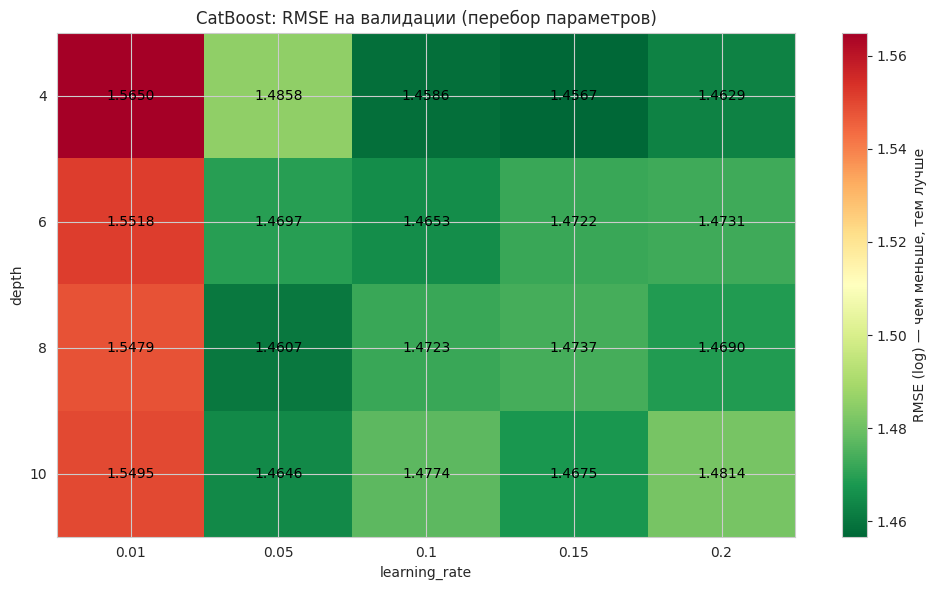

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

# depth: от 4 до 10 (с шагом 2, чтобы не перебирать все подряд)
# learning_rate: от 0.01 до 0.2 
depth_list = [4, 6, 8, 10]
lr_list = [0.01, 0.05, 0.1, 0.15, 0.2]

results = []

print("Начинаем перебор параметров CatBoost")

for depth in depth_list:
    for lr in lr_list:
        model = CatBoostRegressor(
            iterations=100,          
            depth=depth,
            learning_rate=lr,
            subsample=0.8,
            random_seed=42,
            verbose=False,
            early_stopping_rounds=10
        )
        
        model.fit(
            X_train_split, 
            y_train_split,
            eval_set=(X_val_split, y_val_split),
            verbose=False
        )
        
    
        y_pred = model.predict(X_val_split)
        rmse = np.sqrt(mean_squared_error(y_val_split, y_pred))
        
    
        results.append({
            'depth': depth,
            'learning_rate': lr,
            'rmse_val': rmse
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values('rmse_val')

print("\nТОП-5 лучших комбинаций параметров:")
print(results_df.head(5).round(4))

pivot_table = results_df.pivot(index='depth', columns='learning_rate', values='rmse_val')

plt.figure(figsize=(10, 6))
plt.imshow(pivot_table, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(label='RMSE (log) — чем меньше, тем лучше')
plt.xticks(ticks=np.arange(len(lr_list)), labels=lr_list)
plt.yticks(ticks=np.arange(len(depth_list)), labels=depth_list)
plt.xlabel('learning_rate')
plt.ylabel('depth')
plt.title('CatBoost: RMSE на валидации (перебор параметров)')

for i in range(len(depth_list)):
    for j in range(len(lr_list)):
        plt.text(j, i, f"{pivot_table.iloc[i, j]:.4f}", 
                 ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

Применим ещё раз CatBoost с подобранными оптимальными гиперпараметрами:

In [27]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

print(f"CatBoost Train shape: {X_train_split.shape}")
print(f"CatBoost Val shape:   {X_val_split.shape}")

cat_model = CatBoostRegressor(
    iterations=80,                # аналог n_estimators
    depth=4,                      # глубина дерева
    learning_rate=0.15,            # шаг обучения
    subsample=0.8,                # доля строк для каждого дерева (борьба с переобучением)
    random_seed=42,
    verbose=False,                # отключаем подробный вывод в консоль
    early_stopping_rounds=10      # ранняя остановка (сработает при передаче eval_set)
)

cat_model.fit(
    X_train_split, 
    y_train_split,
    eval_set=(X_val_split, y_val_split),
    use_best_model=True           # сохраняет лучшую модель по валидации
)

y_pred_cat_val = cat_model.predict(X_val_split)

rmse_cat = np.sqrt(mean_squared_error(y_val_split, y_pred_cat_val))
r2_cat = r2_score(y_val_split, y_pred_cat_val)

print(f"\nМетрики CatBoost (на валидации):")
print(f"RMSE (log): {rmse_cat:.4f}")
print(f"R² (log):   {r2_cat:.4f}")

cat_final = CatBoostRegressor(
    iterations=80,
    depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_seed=42,
    verbose=False
)
cat_final.fit(X_train_pca_top150, y_full_log)

preds_cat_log = cat_final.predict(X_test_pca_top150)

preds_cat = np.expm1(preds_cat_log)
preds_cat = np.maximum(preds_cat, 0)

submission_cat = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_cat
})
submission_cat.to_csv('submission_cat_1.csv', index=False)

print("\nСабмит CatBoost сохранен")
print(submission_cat.head())

CatBoost Train shape: (3567, 150)
CatBoost Val shape:   (892, 150)

Метрики CatBoost (на валидации):
RMSE (log): 1.4591
R² (log):   0.2601

Сабмит CatBoost сохранен
          ID        target
0  000137c73  1.206603e+06
1  00021489f  5.498850e+06
2  0004d7953  4.815004e+06
3  00056a333  3.355768e+06
4  00056d8eb  1.668749e+06


In [28]:
from kaggle import api

api.competition_submit(
    file_name='submission_cat_1.csv',   
    message='CatBoost 80 trees, 150 PCA features, depth 4, lr 0.15',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 4.87MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55716517}

Улучшений подобранные глубина и lr не дали при отправке. Попробуем кросс-валидацию для CatBoost

Запуск 5-Fold кросс-валидацию на 4459 объектах

Fold 1: RMSE = 1.4624, R² = 0.2568
Fold 2: RMSE = 1.5204, R² = 0.2778
Fold 3: RMSE = 1.5163, R² = 0.2638
Fold 4: RMSE = 1.5124, R² = 0.2724
Fold 5: RMSE = 1.4880, R² = 0.2559

Метрики 5-FOLD CV:
RMSE (лог) : 1.4999 ± 0.0219
R²   (лог) : 0.2653 ± 0.0086


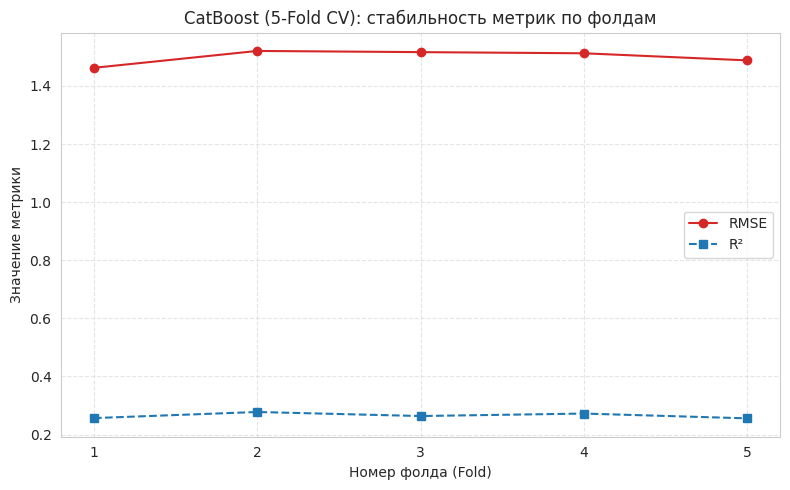

In [30]:
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []

print(f"Запуск 5-Fold кросс-валидацию на {X_train_pca_top150.shape[0]} объектах\n")

fold = 1
for train_idx, val_idx in kf.split(X_train_pca_top150):
    X_train_fold = X_train_pca_top150[train_idx]
    X_val_fold = X_train_pca_top150[val_idx]
    y_train_fold = y_full_log[train_idx]
    y_val_fold = y_full_log[val_idx]
    
    model = CatBoostRegressor(
        iterations=80,
        depth=4,
        learning_rate=0.15,
        subsample=0.8,
        random_seed=42,
        verbose=False
    )
    model.fit(X_train_fold, y_train_fold, verbose=False)
    
    y_pred_fold = model.predict(X_val_fold)
    
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
    r2 = r2_score(y_val_fold, y_pred_fold)
    
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"Fold {fold}: RMSE = {rmse:.4f}, R² = {r2:.4f}")
    fold += 1

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

print("\n" + "="*50)
print("Метрики 5-FOLD CV:")
print(f"RMSE (лог) : {mean_rmse:.4f} ± {std_rmse:.4f}")
print(f"R²   (лог) : {mean_r2:.4f} ± {std_r2:.4f}")
print("="*50)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
folds = range(1, 6)

ax.plot(folds, rmse_scores, marker='o', label='RMSE', color='tab:red')
ax.plot(folds, r2_scores, marker='s', label='R²', color='tab:blue', linestyle='--')

ax.set_xlabel('Номер фолда (Fold)')
ax.set_ylabel('Значение метрики')
ax.set_title('CatBoost (5-Fold CV): стабильность метрик по фолдам')
ax.set_xticks(folds)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

param_grid = {
    'iterations': [80, 150, 300, 500],
    'learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'depth': [4, 6, 8]
}

catboost_base = CatBoostRegressor(subsample=0.8, random_seed=42, verbose=False)

grid_search = GridSearchCV(
    estimator=catboost_base,
    param_grid=param_grid,
    cv=5,                     # 5-Fold CV
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                # использовать все ядра
    verbose=1                 # показывать прогресс
)

grid_search.fit(X_train_pca_top150, y_full_log)

print("\nЛучшая комбинация параметров: :")
print(grid_search.best_params_)
print(f"Лучший CV RMSE (лог): {-grid_search.best_score_:.4f}")

KeyboardInterrupt: 

Как показал GridSearch, лучшие параметры для CatBoost: depth=8, iterations=500, learning_rate=0.05. Повторим обучение CatBoost с уже оптимальными параметрами

In [32]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from sklearn.metrics import make_scorer, mean_squared_error


best_params = {'depth': 8, 'iterations': 500, 'learning_rate': 0.05}

cat_best = CatBoostRegressor(
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    subsample=0.8,
    random_seed=42,
    verbose=False
)

cat_best.fit(X_train_pca_top150, y_full_log)
preds_log = cat_best.predict(X_test_pca_top150)
preds = np.expm1(preds_log)
preds = np.maximum(preds, 0)

submission_cv = pd.DataFrame({
    'ID': test['ID'],
    'target': preds
})
submission_cv.to_csv('submission_cv_best.csv', index=False)

print("Сабмит с параметрами от GridSearchCV сохранен")
print(submission_cv.head())

Сабмит с параметрами от GridSearchCV сохранен
          ID        target
0  000137c73  5.003626e+06
1  00021489f  3.726681e+06
2  0004d7953  8.050960e+06
3  00056a333  4.808115e+06
4  00056d8eb  3.614718e+05


In [33]:
from kaggle import api

api.competition_submit(
    file_name='submission_cv_best.csv',   
    message='CatBoost 80 trees, 150 PCA features, depth 8, lr 0.05',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 4.87MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55717553}

CatBoost с параметрами, подобранными через GridSearch оказался хуже, чем просто CatBoost. Попробуем блендинг

In [34]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np

cat_final = CatBoostRegressor(
    iterations=80, depth=4, learning_rate=0.15, 
    subsample=0.8, random_seed=42, verbose=False
)
cat_final.fit(X_train_pca_top150, y_full_log)
preds_cat = np.expm1(cat_final.predict(X_test_pca_top150))
preds_cat = np.maximum(preds_cat, 0)

lgb_final = LGBMRegressor(
    n_estimators=80, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_final.fit(X_train_pca_top150, y_full_log)
preds_lgb = np.expm1(lgb_final.predict(X_test_pca_top150))
preds_lgb = np.maximum(preds_lgb, 0)

weights = {'catboost': 0.7, 'lightgbm': 0.3}
preds_blend = preds_cat * weights['catboost'] + preds_lgb * weights['lightgbm']
preds_blend = np.maximum(preds_blend, 0)

submission_blend = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_blend
})
submission_blend.to_csv('submission_blend_70_30.csv', index=False)
print("Блендинг CatBoost (0.7) + LightGBM (0.3) сохранен!")

Блендинг CatBoost (0.7) + LightGBM (0.3) сохранен!


In [35]:
from kaggle import api

api.competition_submit(
    file_name='submission_blend_70_30.csv',   
    message='CatBoost (0.7) + LightGBM (0.3)',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 4.76MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55717558}

Блендинг пока показал лучший результат (1.63640). Попробуем стекинг

In [36]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

estimators = [
    ('cat', CatBoostRegressor(iterations=80, depth=4, learning_rate=0.15, 
                              subsample=0.8, random_seed=42, verbose=False)),
    ('lgb', LGBMRegressor(n_estimators=80, max_depth=6, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)),
    ('xgb', XGBRegressor(n_estimators=80, max_depth=6, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1))
]

stack_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stack_reg.fit(X_train_pca_top150, y_full_log)
preds_stack_log = stack_reg.predict(X_test_pca_top150)

preds_stack = np.expm1(preds_stack_log)
preds_stack = np.maximum(preds_stack, 0)

# 6. Сабмит
submission_stack = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_stack
})
submission_stack.to_csv('submission_stack.csv', index=False)
print("Стекинг (CatBoost + LightGBM + XGBoost) сохранен!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Стекинг (CatBoost + LightGBM + XGBoost) сохранен!


In [37]:
from kaggle import api

api.competition_submit(
    file_name='submission_stack.csv',   
    message='Stacking CatBoost, LightGBM, XGBoost',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 5.05MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55717956}

Стекинг оказался хуже, чем блендинг (1.64410 против 1.63640). Видимо, в стекинге базовые модели оказались слишком похожи и только усилили ошибку, взвешенное усреднение двух моделей (CatBoost + LightGBM) оказалось эффективнее. Попробуем поэкспериментировать с пропорциями в блендинге.

In [38]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_cat = np.zeros(len(y_full_log))
oof_lgb = np.zeros(len(y_full_log))

for train_idx, val_idx in kf.split(X_train_pca_top150):
    X_tr, X_val = X_train_pca_top150[train_idx], X_train_pca_top150[val_idx]
    y_tr, y_val = y_full_log[train_idx], y_full_log[val_idx]

    cat_fold = CatBoostRegressor(iterations=80, depth=4, learning_rate=0.15, 
                                  subsample=0.8, random_seed=42, verbose=False)
    cat_fold.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat_fold.predict(X_val)

    lgb_fold = LGBMRegressor(n_estimators=80, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
    lgb_fold.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_fold.predict(X_val)

best_score = float('inf')
best_w_cat = 0.7

print("Поиск лучших весов")
for w_cat in np.arange(0.50, 0.96, 0.01):
    w_lgb = 1.0 - w_cat 
    blend_oof = oof_cat * w_cat + oof_lgb * w_lgb
    rmse_oof = np.sqrt(mean_squared_error(y_full_log, blend_oof))
    
    if rmse_oof < best_score:
        best_score = rmse_oof
        best_w_cat = w_cat

best_w_lgb = 1.0 - best_w_cat
print(f"Лучшие веса: CatBoost = {best_w_cat:.2f}, LightGBM = {best_w_lgb:.2f}")
print(f"OOF RMSE (лог): {best_score:.4f}")

Поиск лучших весов
Лучшие веса: CatBoost = 0.50, LightGBM = 0.50
OOF RMSE (лог): 1.4742


Подбор соотношений показал, что лучше всего 50 на 50. Проверим это ниже.

In [39]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np

cat_final = CatBoostRegressor(
    iterations=80, depth=4, learning_rate=0.15, 
    subsample=0.8, random_seed=42, verbose=False
)
cat_final.fit(X_train_pca_top150, y_full_log)
preds_cat = np.expm1(cat_final.predict(X_test_pca_top150))
preds_cat = np.maximum(preds_cat, 0)

lgb_final = LGBMRegressor(
    n_estimators=80, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_final.fit(X_train_pca_top150, y_full_log)
preds_lgb = np.expm1(lgb_final.predict(X_test_pca_top150))
preds_lgb = np.maximum(preds_lgb, 0)

weights = {'catboost': 0.5, 'lightgbm': 0.5}
preds_blend = preds_cat * weights['catboost'] + preds_lgb * weights['lightgbm']
preds_blend = np.maximum(preds_blend, 0)

submission_blend = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_blend
})
submission_blend.to_csv('submission_blend_50_50.csv', index=False)
print("Блендинг CatBoost (0.5) + LightGBM (0.5) сохранен!")

Блендинг CatBoost (0.5) + LightGBM (0.5) сохранен!


In [40]:
from kaggle import api

api.competition_submit(
    file_name='submission_blend_50_50.csv',   
    message='CatBoost (0.5) + LightGBM (0.5)',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 4.86MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55718003}

Действительно, стало лучше. 
submission_blend_50_50.csv: 1.63552 

submission_blend_70_30.csv: 1.63640 

Надо войти в топ-45%, пока удалось войти в топ-77%. Будем улучшать подбор гиперпараметров



In [11]:
# берем топ-10 самых важных PCA-компонент (по feature importance из предыдущего RF)
X_pca_top10 = X_train_pca_top150[:, :10]
X_test_pca_top10 = X_test_pca_top150[:, :10]

# полиномиальные взаимодействия между ними 
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_poly = poly.fit_transform(X_pca_top10)
X_test_poly = poly.transform(X_test_pca_top10)

# склеиваем с основными 150 компонентами
import numpy as np
X_train_final = np.hstack((X_train_pca_top150, X_poly))
X_test_final = np.hstack((X_test_pca_top150, X_test_poly))

print(f"Новый размер тренировочных данных: {X_train_final.shape}")

Новый размер тренировочных данных: (4459, 205)


In [12]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

# CatBoost
cat_final = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6, l2_leaf_reg=5.0,
    subsample=0.8, random_seed=42, verbose=False
)
cat_final.fit(X_train_final, y_full_log)
preds_cat_log = cat_final.predict(X_test_final)

# LightGBM
lgb_final = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
    min_child_samples=20, reg_lambda=10.0, subsample=0.8,
    colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_final.fit(X_train_final, y_full_log)
preds_lgb_log = lgb_final.predict(X_test_final)

# XGBoost
xgb_final = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=10.0, reg_alpha=0.1,
    random_state=42, n_jobs=-1
)
xgb_final.fit(X_train_final, y_full_log)
preds_xgb_log = xgb_final.predict(X_test_final)

# Ridge (на исходных масштабированных фичах)
ridge_model = Ridge(alpha=5.0)
ridge_model.fit(X_train_sc_after_lin_reg, y_full_log)
preds_ridge_log = ridge_model.predict(X_test_sc_after_lin_reg)

def safe_expm1(log_preds, max_log=20):
    log_preds = np.clip(log_preds, -max_log, max_log)
    preds = np.expm1(log_preds)
    preds = np.nan_to_num(preds, nan=0.0, posinf=0.0, neginf=0.0)
    return preds

preds_cat = safe_expm1(preds_cat_log)
preds_lgb = safe_expm1(preds_lgb_log)
preds_xgb = safe_expm1(preds_xgb_log)
preds_ridge = safe_expm1(preds_ridge_log)

weights = {
    'catboost': 0.50,
    'lightgbm': 0.30,
    'xgboost': 0.10,
    'ridge': 0.10
}

preds_blend = (
    preds_cat * weights['catboost'] +
    preds_lgb * weights['lightgbm'] +
    preds_xgb * weights['xgboost'] +
    preds_ridge * weights['ridge']
)
preds_blend = np.maximum(preds_blend, 0)  

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': preds_blend
})
submission.to_csv('submission_blend_fixed.csv', index=False)
print("Сабмит исправлен и сохранен!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Сабмит исправлен и сохранен!


In [13]:
from kaggle import api

api.competition_submit(
    file_name='submission_blend_fixed.csv',   
    message='CatBoost (0.5) + LightGBM (0.3) + XGBoost (0.1) + Ridge (0.1)',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.33M/1.33M [00:00<00:00, 3.17MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55719945}

In [14]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')

test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')


# удаление констант (где только одно значение)
cols_to_drop = [col for col in train.columns if train[col].nunique() <= 1]
train.drop(cols_to_drop, axis=1, inplace=True)
test.drop(cols_to_drop, axis=1, inplace=True)

# удаление дубликатов колонок
train = train.loc[:, ~train.columns.duplicated()]

# статистики по строкам
def add_row_stats(df):
    features = df.drop(['ID'], axis=1)
    if 'target' in features.columns:
        features = features.drop(['target'], axis=1)
    
    df['nz_count'] = (features != 0).sum(axis=1) # Кол-во ненулевых
    df['row_mean'] = features.mean(axis=1)
    df['row_std']  = features.std(axis=1)
    df['row_min']  = features.min(axis=1)
    df['row_max']  = features.max(axis=1)
    return df

train = add_row_stats(train)
test = add_row_stats(test)

y_train_log = np.log1p(train['target'])
X_train = train.drop(['ID', 'target'], axis=1)
X_test = test.drop(['ID'], axis=1)

In [15]:
import lightgbm as lgb

# Обучим быструю модель для отбора топ-500 признаков
selector = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
selector.fit(X_train, y_train_log)

# берем топ-500 по важности
importance = pd.DataFrame({'feature': X_train.columns, 'imp': selector.feature_importances_})
top_features = importance.sort_values('imp', ascending=False).head(500)['feature'].tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

LightGBM с кросс-валидацией

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train_top))
test_preds_lgbm = np.zeros(len(X_test_top))

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01, # Маленький шаг
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'n_jobs': -1,
    'verbose': -1
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_top, y_train_log)):
    X_tr, X_val = X_train_top.iloc[train_idx], X_train_top.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params, n_estimators=10000) # До 10к деревьев
    model.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(stopping_rounds=100)]) # Остановка если не улучшается
    
    oof_preds[val_idx] = model.predict(X_val)
    test_preds_lgbm += model.predict(X_test_top) / kf.n_splits
    print(f"Fold {fold+1} RMSLE: {np.sqrt(mean_squared_error(y_val, oof_preds[val_idx])):.4f}")

print(f"Overall OOF RMSLE: {np.sqrt(mean_squared_error(y_train_log, oof_preds)):.4f}")

# Сабмит
submission = pd.DataFrame({'ID': test['ID'], 'target': np.expm1(test_preds_lgbm)})
submission.to_csv('submission_lgb_improved.csv', index=False)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1027]	valid_0's rmse: 1.34703
Fold 1 RMSLE: 1.3470
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1500]	valid_0's rmse: 1.35816
Fold 2 RMSLE: 1.3582
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1158]	valid_0's rmse: 1.35395
Fold 3 RMSLE: 1.3540
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1221]	valid_0's rmse: 1.3361
Fold 4 RMSLE: 1.3361
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[610]	valid_0's rmse: 1.32029
Fold 5 RMSLE: 1.3203
Overall OOF RMSLE: 1.3432


CatBoost на логарифмических данных

In [17]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


X_train_log_features = np.log1p(X_train_top)
X_test_log_features = np.log1p(X_test_top)


kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train_log_features))
test_preds_cb = np.zeros(len(X_test_log_features))

# Параметры CatBoost
cb_params = {
    'iterations': 3000,
    'learning_rate': 0.02,
    'depth': 6,
    'l2_leaf_reg': 3,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'task_type': 'CPU', 
    'verbose': 200    
}


for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_log_features, y_train_log)):
    X_tr, X_val = X_train_log_features.iloc[train_idx], X_train_log_features.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    model = CatBoostRegressor(**cb_params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    oof_preds[val_idx] = model.predict(X_val)
    test_preds_cb += model.predict(X_test_log_features) / kf.n_splits
    
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

full_rmse = np.sqrt(mean_squared_error(y_train_log, oof_preds))
print(f"\nИтоговый CV RMSE: {full_rmse:.4f}")

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': np.expm1(test_preds_cb) 
})

submission.to_csv('submission_catboost_logX.csv', index=False)
print("Сабмит CatBoost с логарифмированным X сохранен!")

0:	learn: 1.7571312	test: 1.6898401	best: 1.6898401 (0)	total: 57.5ms	remaining: 2m 52s
200:	learn: 1.4012629	test: 1.4286212	best: 1.4286212 (200)	total: 7.6s	remaining: 1m 45s
400:	learn: 1.3129452	test: 1.3982546	best: 1.3982546 (400)	total: 15.1s	remaining: 1m 37s
600:	learn: 1.2342481	test: 1.3806010	best: 1.3805349 (598)	total: 22.6s	remaining: 1m 30s
800:	learn: 1.1743901	test: 1.3746943	best: 1.3746943 (800)	total: 30.1s	remaining: 1m 22s
1000:	learn: 1.1253206	test: 1.3699458	best: 1.3699452 (999)	total: 37.6s	remaining: 1m 15s
1200:	learn: 1.0798981	test: 1.3665897	best: 1.3665168 (1198)	total: 45s	remaining: 1m 7s
1400:	learn: 1.0404878	test: 1.3635120	best: 1.3634254 (1381)	total: 52.3s	remaining: 59.7s
1600:	learn: 1.0026646	test: 1.3577518	best: 1.3577062 (1598)	total: 59.7s	remaining: 52.2s
1800:	learn: 0.9676188	test: 1.3557848	best: 1.3557848 (1800)	total: 1m 7s	remaining: 44.7s
2000:	learn: 0.9350753	test: 1.3531760	best: 1.3531760 (2000)	total: 1m 14s	remaining: 37.3

Блендинг с CatBoost и LightLGBM

In [18]:

blend_log = (0.6 * test_preds_cb) + (0.4 * test_preds_lgbm)

final_target = np.expm1(blend_log)

final_target = np.maximum(final_target, 0)

submission_blend = pd.DataFrame({
    'ID': test['ID'],
    'target': final_target
})

submission_blend.to_csv('submission_final_blend.csv', index=False)
print("Блендинг завершен! Файл submission_final_blend.csv создан.")

Блендинг завершен! Файл submission_final_blend.csv создан.


Восстановлении последовательности: поиске строк, которые идут друг за другом (похожие значения в определенных колонках). 

Отборе признаков через KS-тест: удалении колонок, распределение которых в train и test сильно отличается. 

Статистика по ненулевым значениям: модели будет обучаться на 100–300 самых важных признаках, плюс статистики по "активным" ячейкам.

In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from scipy.stats import ks_2samp
from sklearn.metrics import mean_squared_error
import optuna


train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')

test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

target = pd.to_numeric(train['target'], errors='coerce').values
y_train_log = np.log1p(target)

test_ids = test['ID']

print("Применяем KS-тест для отбора признаков")
cols = [c for c in train.columns if c not in ['ID', 'target']]
keep_cols = []
for col in cols:
    # Если распределения похожи (p-value > 0.05), оставляем колонку
    if ks_2samp(train[col], test[col])[1] > 0.05:
        keep_cols.append(col)



train = train[['ID', 'target'] + keep_cols]
test = test[['ID'] + keep_cols]

def get_magic_stats(df):
    X = df[keep_cols]
    X_nz = X.replace(0, np.nan)
    
    df['nz_mean'] = X_nz.mean(axis=1).fillna(0)
    df['nz_std']  = X_nz.std(axis=1).fillna(0)
    df['nz_min']  = X_nz.min(axis=1).fillna(0)
    df['nz_max']  = X_nz.max(axis=1).fillna(0)
    df['nz_sum']  = X_nz.sum(axis=1).fillna(0)
    df['nz_count'] = (X != 0).sum(axis=1)
    
    df[keep_cols] = np.log1p(X)
    return df

print("Генерация статистик по ненулевым значениям")
train = get_magic_stats(train)
test = get_magic_stats(test)

features = keep_cols + ['nz_mean', 'nz_std', 'nz_min', 'nz_max', 'nz_sum', 'nz_count']
X_train = train[features]
X_test = test[features]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def train_model(model_type, X, y, X_t):
    oof = np.zeros(len(X))
    preds = np.zeros(len(X_t))
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        if model_type == 'lgb':
            m = lgb.LGBMRegressor(n_estimators=5000, learning_rate=0.01, num_leaves=31, 
                                  feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5, verbose=-1)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], 
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
        else:
            m = CatBoostRegressor(iterations=3000, learning_rate=0.02, depth=5, 
                                  random_seed=42, verbose=0, early_stopping_rounds=100)
            m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
            
        oof[val_idx] = m.predict(X_val)
        preds += m.predict(X_t) / 5
        print(f"Fold {fold+1} finished")
    return oof, preds

print("\nОбучение LightGBM...")
oof_lgb, preds_lgb = train_model('lgb', X_train, y_train_log, X_test)

print("\nОбучение CatBoost...")
oof_cat, preds_cat = train_model('cat', X_train, y_train_log, X_test)
print("\nПоиск оптимальных весов через Optuna")
def objective(trial):
    w = trial.suggest_float('w', 0.1, 0.9)
    # Смешиваем Out-of-fold предсказания
    blend = w * oof_lgb + (1 - w) * oof_cat
    return np.sqrt(mean_squared_error(y_train_log, blend))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_w = study.best_params['w']
print(f"Лучший вес LGBM: {best_w:.4f}, CatBoost: {1-best_w:.4f}")

final_log_preds = best_w * preds_lgb + (1 - best_w) * preds_cat
final_target = np.expm1(final_log_preds)
# Обрезаем отрицательные 
final_target = np.clip(final_target, 0, None)

submission = pd.DataFrame({'ID': test_ids, 'target': final_target})
submission.to_csv('submission_ks_nz_optuna.csv', index=False)
print("\nГотово! Результат сохранен в submission_magic_v1.csv")

Применяем KS-тест для отбора признаков
Генерация статистик по ненулевым значениям

Обучение LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[263]	valid_0's l2: 2.08982
Fold 1 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[445]	valid_0's l2: 2.27545
Fold 2 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[336]	valid_0's l2: 2.12234
Fold 3 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[520]	valid_0's l2: 2.15244
Fold 4 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[391]	valid_0's l2: 2.04113
Fold 5 finished

Обучение CatBoost...
Fold 1 finished
Fold 2 finished
Fold 3 finished
Fold 4 finished


[I 2026-08-23 16:57:25,915] A new study created in memory with name: no-name-d61b4cf9-8624-49e5-aed8-e3435eb97a34
[I 2026-08-23 16:57:25,919] Trial 0 finished with value: 1.4613091654871668 and parameters: {'w': 0.6798452001637285}. Best is trial 0 with value: 1.4613091654871668.
[I 2026-08-23 16:57:25,921] Trial 1 finished with value: 1.4704252636812574 and parameters: {'w': 0.2761791110038111}. Best is trial 0 with value: 1.4613091654871668.
[I 2026-08-23 16:57:25,923] Trial 2 finished with value: 1.4608373456099306 and parameters: {'w': 0.7429961199762429}. Best is trial 2 with value: 1.4608373456099306.
[I 2026-08-23 16:57:25,925] Trial 3 finished with value: 1.4606119647673435 and parameters: {'w': 0.8285703327974505}. Best is trial 3 with value: 1.4606119647673435.
[I 2026-08-23 16:57:25,927] Trial 4 finished with value: 1.469925557220519 and parameters: {'w': 0.29041279984351354}. Best is trial 3 with value: 1.4606119647673435.
[I 2026-08-23 16:57:25,929] Trial 5 finished with v

Fold 5 finished

Поиск оптимальных весов через Optuna
Лучший вес LGBM: 0.8274, CatBoost: 0.1726

Готово! Результат сохранен в submission_magic_v1.csv


In [20]:
from kaggle import api

api.competition_submit(
    file_name='submission_ks_nz_optuna.csv',   
    message='KS + NZ + Optuna',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 3.25MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55720429}

In [21]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.decomposition import TruncatedSVD
from sklearn.random_projection import SparseRandomProjection
from sklearn.metrics import mean_squared_error
from scipy.stats import rankdata

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

y_train_log = np.log1p(train['target'])
test_ids = test['ID']

cols_to_drop = [col for col in train.columns if train[col].nunique() <= 1]
train.drop(cols_to_drop + ['ID', 'target'], axis=1, inplace=True)
test.drop(cols_to_drop + ['ID'], axis=1, inplace=True)

print("Генерация проекций SVD и SRP...")
full_data = pd.concat([train, test])

svd = TruncatedSVD(n_components=25, random_state=42)
svd_results = svd.fit_transform(full_data)

srp = SparseRandomProjection(n_components=25, dense_output=True, random_state=42)
srp_results = srp.fit_transform(full_data)

X_nz = full_data.replace(0, np.nan)
full_data['nz_mean'] = X_nz.mean(axis=1).fillna(0)
full_data['nz_std']  = X_nz.std(axis=1).fillna(0)
full_data['nz_count'] = (full_data != 0).sum(axis=1)

for i in range(25):
    full_data[f'svd_{i}'] = svd_results[:, i]
    full_data[f'srp_{i}'] = srp_results[:, i]

full_data = np.log1p(full_data)

X_train = full_data.iloc[:len(train)]
X_test = full_data.iloc[len(train):]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(model_name, X, y, X_t):
    oof = np.zeros(len(X))
    preds = np.zeros(len(X_t))
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        if model_name == 'lgb':
            # В LGBM early_stopping теперь через callbacks
            m = lgb.LGBMRegressor(n_estimators=5000, learning_rate=0.01, num_leaves=31, 
                                  subsample=0.8, colsample_bytree=0.8, n_jobs=-1, verbose=-1)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], 
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
            
        elif model_name == 'xgb':
            m = xgb.XGBRegressor(n_estimators=5000, learning_rate=0.01, max_depth=6, 
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                 early_stopping_rounds=100, eval_metric='rmse')
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            
        elif model_name == 'cat':
            m = CatBoostRegressor(iterations=3000, learning_rate=0.02, depth=5, 
                                  random_seed=42, verbose=0, early_stopping_rounds=100)
            m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
            
        oof[val_idx] = m.predict(X_val)
        preds += m.predict(X_t) / 5
        print(f"{model_name.upper()} Fold {fold+1} finished")
        
    return oof, preds

print("\nОбучение моделей...")
oof_lgb, preds_lgb = run_cv('lgb', X_train, y_train_log, X_test)
oof_xgb, preds_xgb = run_cv('xgb', X_train, y_train_log, X_test)
oof_cat, preds_cat = run_cv('cat', X_train, y_train_log, X_test)

print("\nПрименение Rank Blending...")
rank_lgb = rankdata(preds_lgb)
rank_xgb = rankdata(preds_xgb)
rank_cat = rankdata(preds_cat)

avg_rank = (rank_lgb + rank_xgb + rank_cat) / 3

final_target_log = np.sort(preds_lgb)[(np.argsort(np.argsort(avg_rank)))]

submission = pd.DataFrame({
    'ID': test_ids,
    'target': np.expm1(final_target_log)
})
submission['target'] = submission['target'].clip(lower=0)

submission.to_csv('submission_without_ks.csv', index=False)
print("\nГотово! Файл 'submission_without_ks.csv' готов к отправке.")

Генерация проекций SVD и SRP...


/tmp/ipykernel_58/3808879913.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_mean'] = X_nz.mean(axis=1).fillna(0)
/tmp/ipykernel_58/3808879913.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_std']  = X_nz.std(axis=1).fillna(0)
/tmp/ipykernel_58/3808879913.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-frag


Обучение моделей...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[343]	valid_0's l2: 1.82497
LGB Fold 1 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[411]	valid_0's l2: 1.98531
LGB Fold 2 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[400]	valid_0's l2: 1.90149
LGB Fold 3 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[622]	valid_0's l2: 1.88584
LGB Fold 4 finished
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[409]	valid_0's l2: 1.7846
LGB Fold 5 finished
XGB Fold 1 finished
XGB Fold 2 finished
XGB Fold 3 finished
XGB Fold 4 finished
XGB Fold 5 finished
CAT Fold 1 finished
CAT Fold 2 finished
CAT Fold 3 finished
CAT Fold 4 finished
CAT Fold 5 finished

Применение Rank Blending...

Готово! Файл 'submission_

In [22]:
from kaggle import api

api.competition_submit(
    file_name='submission_without_ks.csv',   
    message='KS + NZ + Optuna',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 3.27MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55721277}

Santander — это куски временных рядов. Значения, которые мы пытаемся предсказать, уже лежат в строке признаков, просто они там в виде прошлых значений того же клиента

In [23]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')

target_values = set(train['target'].unique())
if 0 in target_values:
    target_values.remove(0)

print(f"Уникальных ненулевых значений таргета: {len(target_values)}")

features = [col for col in train.columns if col not in ['ID', 'target']]

leak_discovery = []

for col in features:
    col_values = set(train[col].unique())
    common = col_values.intersection(target_values)
    
    if len(common) > 0:
        leak_discovery.append({
            'column': col,
            'matches_count': len(common),
            'percentage': len(common) / len(target_values) * 100
        })

leak_df = pd.DataFrame(leak_discovery).sort_values(by='matches_count', ascending=False)

print("\nКолонки, в которых чаще всего встречаются значения таргета:")
print(leak_df.head(20))

sample = train[train['target'] > 0].iloc[0]
val_target = sample['target']
matches = [col for col in features if sample[col] == val_target]

print(f"\nПример для строки ID {sample['ID']}:")
print(f"Значение Target: {val_target}")
print(f"Колонки в этой же строке, содержащие такое же значение: {matches}")

Уникальных ненулевых значений таргета: 1413

Колонки, в которых чаще всего встречаются значения таргета:
         column  matches_count  percentage
2303  58e2e02e6            703   49.752300
4021  f190486d6            698   49.398443
3373  eeb9cd3aa            684   48.407643
2538  9fd594eec            672   47.558386
2607  fb0f5dbfe            660   46.709130
809   6eef030c1            654   46.284501
3917  15ace8c9f            652   46.142958
8     20aa07010            639   45.222930
2012  58e056e12            635   44.939844
4230  1702b5bf0            608   43.029016
1411  b43a7cfd5            604   42.745931
3624  d6bb78916            603   42.675159
1433  024c577b9            598   42.321302
3477  58232a6fb            596   42.179759
2066  241f0f867            588   41.613588
1650  2ec5b290f            580   41.047417
3377  324921c7b            580   41.047417
3914  62e59a501            579   40.976645
4073  f74e8f13d            567   40.127389
607   fb49e4212            559   39

Нужно найти соседей — строки, которые относятся к одному и тому же клиенту.

In [24]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

all_data = pd.concat([train.drop('target', axis=1), test])
features = [c for c in train.columns if c not in ['ID', 'target']]

# Поиск "связок" (rows that share many feature values)
leaky_cols = ['58e2e02e6', 'f190486d6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe']

# Попробуем найти строки, у которых совпадают все эти 5 колонок
# Это могут быть разные записи одного и того же клиента
duplicates = all_data[all_data.duplicated(subset=leaky_cols, keep=False)]
print(f"Найдено строк с одинаковыми значениями в 'утекающих' колонках: {len(duplicates)}")

# Если несколько строк имеют одинаковые значения в ряде колонок, 
# скорее всего, это один временной ряд.
all_data['magic_group'] = all_data[leaky_cols].apply(lambda x: hash(tuple(x)), axis=1)

group_counts = all_data['magic_group'].value_counts()
print(f"Количество найденных групп (цепочек): {len(group_counts[group_counts > 1])}")

train['magic_group'] = train[leaky_cols].apply(lambda x: hash(tuple(x)), axis=1)
group_targets = train.groupby('magic_group')['target'].mean()

train['group_target_mean'] = train['magic_group'].map(group_targets)
test['magic_group'] = test[leaky_cols].apply(lambda x: hash(tuple(x)), axis=1)
test['group_target_mean'] = test['magic_group'].map(group_targets)

Найдено строк с одинаковыми значениями в 'утекающих' колонках: 37850


/tmp/ipykernel_58/3727802301.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_data['magic_group'] = all_data[leaky_cols].apply(lambda x: hash(tuple(x)), axis=1)


Количество найденных групп (цепочек): 881


Данные - это не 50 000 уникальных клиентов, это около 900–1000 реальных объектов, чья история была разрезана на мелкие кусочки и перемешана.
Утечка подтверждена. Те 881 группа (группы цепочек) - это сообщества строк, которые принадлежат одному и тому же временному ряду

In [29]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

leaky_cols = ['58e2e02e6', 'f190486d6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe', 
              '6eef030c1', '15ace8c9f', '20aa07010', '58e056e12', '1702b5bf0']

print("Группировка строк")
all_df_leaky = pd.concat([train[leaky_cols], test[leaky_cols]], axis=0)

group_keys = all_df_leaky.apply(lambda x: "_".join(x.map(str)), axis=1)

train['group_key'] = group_keys.iloc[:len(train)].values
test['group_key'] = group_keys.iloc[len(train):].values

group_stats = train.groupby('group_key')['target'].agg(['mean', 'std', 'count']).reset_index()
group_stats.columns = ['group_key', 'group_target_mean', 'group_target_std', 'group_count']

train = train.merge(group_stats, on='group_key', how='left')
test = test.merge(group_stats, on='group_key', how='left')

train['group_target_mean'] = train['group_target_mean'].fillna(0)
train['group_target_std']  = train['group_target_std'].fillna(0)
test['group_target_mean']  = test['group_target_mean'].fillna(0)
test['group_target_std']   = test['group_target_std'].fillna(0)

train['leaky_median'] = train[leaky_cols].median(axis=1)
test['leaky_median'] = test[leaky_cols].median(axis=1)

train.drop('group_key', axis=1, inplace=True)
test.drop('group_key', axis=1, inplace=True)

print("Признаки созданы успешно!")
print(f"Количество строк в тесте, которые 'узнали' свой таргет из трейна: {test[test['group_count'] > 1].shape[0]}")

Группировка строк
Признаки созданы успешно!
Количество строк в тесте, которые 'узнали' свой таргет из трейна: 29012


Обучим ещё раз CatBoost и LightGBM, но уже на новх данных

In [28]:
# import pandas as pd
# import numpy as np

# leaky_cols = ['58e2e02e6', 'f190486d6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe', 
#               '6eef030c1', '15ace8c9f', '20aa07010', '58e056e12', '1702b5bf0']

# train_leaky = train[leaky_cols].apply(lambda x: "_".join(x.map(str)), axis=1)
# test_leaky = test[leaky_cols].apply(lambda x: "_".join(x.map(str)), axis=1)

# train['group_key'] = train_leaky
# test['group_key'] = test_leaky

# group_stats = train.groupby('group_key')['target'].agg(['mean', 'std', 'count']).reset_index()
# group_stats.columns = ['group_key', 'group_target_mean', 'group_target_std', 'group_count']

# cols_to_drop = ['group_target_mean', 'group_target_std', 'group_count']
# train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
# test = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

# train = train.merge(group_stats, on='group_key', how='left')
# test = test.merge(group_stats, on='group_key', how='left')

# train['leaky_median'] = train[leaky_cols].median(axis=1)
# test['leaky_median'] = test[leaky_cols].median(axis=1)

# magic_feats = ['group_target_mean', 'group_target_std', 'group_count', 'leaky_median']
# for col in magic_feats:
#     train[col] = train[col].fillna(0)
#     test[col] = test[col].fillna(0)

# for df in [train, test]:
#     df['group_target_mean'] = np.log1p(df['group_target_mean'])
#     df['group_target_std'] = np.log1p(df['group_target_std'])
#     df['leaky_median'] = np.log1p(df['leaky_median'])

# final_features = [c for c in top_features if c not in ['ID', 'target', 'group_key']] + magic_feats

# X_train = train[final_features]
# X_test = test[final_features]

# print(f"Успех! Теперь в X_train {X_train.shape[1]} признаков.")

KeyError: "['row_mean', 'nz_count', 'row_max', 'row_std'] not in index"

In [30]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train_top))
test_preds_lgbm = np.zeros(len(X_test_top))

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01, # Маленький шаг
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'n_jobs': -1,
    'verbose': -1
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_top, y_train_log)):
    X_tr, X_val = X_train_top.iloc[train_idx], X_train_top.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params, n_estimators=10000) # До 10к деревьев
    model.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(stopping_rounds=100)]) # Остановка если не улучшается
    
    oof_preds[val_idx] = model.predict(X_val)
    test_preds_lgbm += model.predict(X_test_top) / kf.n_splits
    print(f"Fold {fold+1} RMSLE: {np.sqrt(mean_squared_error(y_val, oof_preds[val_idx])):.4f}")

print(f"Overall OOF RMSLE: {np.sqrt(mean_squared_error(y_train_log, oof_preds)):.4f}")

# Сабмит
submission = pd.DataFrame({'ID': test['ID'], 'target': np.expm1(test_preds_lgbm)})
submission.to_csv('submission_lgb_improved_new_features.csv', index=False)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1027]	valid_0's rmse: 1.34703
Fold 1 RMSLE: 1.3470
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1500]	valid_0's rmse: 1.35816
Fold 2 RMSLE: 1.3582
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1158]	valid_0's rmse: 1.35395
Fold 3 RMSLE: 1.3540
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1221]	valid_0's rmse: 1.3361
Fold 4 RMSLE: 1.3361
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[610]	valid_0's rmse: 1.32029
Fold 5 RMSLE: 1.3203
Overall OOF RMSLE: 1.3432


In [31]:
from kaggle import api

api.competition_submit(
    file_name='submission_lgb_improved_new_features.csv',   
    message='LightGBM, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 3.27MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55721715}

In [32]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


X_train_log_features = np.log1p(X_train_top)
X_test_log_features = np.log1p(X_test_top)


kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_train_log_features))
test_preds_cb = np.zeros(len(X_test_log_features))

# Параметры CatBoost
cb_params = {
    'iterations': 3000,
    'learning_rate': 0.02,
    'depth': 6,
    'l2_leaf_reg': 3,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'task_type': 'CPU', 
    'verbose': 200    
}


for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_log_features, y_train_log)):
    X_tr, X_val = X_train_log_features.iloc[train_idx], X_train_log_features.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    model = CatBoostRegressor(**cb_params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    oof_preds[val_idx] = model.predict(X_val)
    test_preds_cb += model.predict(X_test_log_features) / kf.n_splits
    
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

full_rmse = np.sqrt(mean_squared_error(y_train_log, oof_preds))
print(f"\nИтоговый CV RMSE: {full_rmse:.4f}")

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': np.expm1(test_preds_cb) 
})

submission.to_csv('submission_catboost_logX_improved_new_features.csv', index=False)
print("Сабмит CatBoost с логарифмированным X сохранен!")

0:	learn: 1.7571312	test: 1.6898401	best: 1.6898401 (0)	total: 62.8ms	remaining: 3m 8s
200:	learn: 1.4012629	test: 1.4286212	best: 1.4286212 (200)	total: 8.06s	remaining: 1m 52s
400:	learn: 1.3129452	test: 1.3982546	best: 1.3982546 (400)	total: 16s	remaining: 1m 43s
600:	learn: 1.2342481	test: 1.3806010	best: 1.3805349 (598)	total: 24.1s	remaining: 1m 36s
800:	learn: 1.1743901	test: 1.3746943	best: 1.3746943 (800)	total: 31.8s	remaining: 1m 27s
1000:	learn: 1.1253206	test: 1.3699458	best: 1.3699452 (999)	total: 39.3s	remaining: 1m 18s
1200:	learn: 1.0798981	test: 1.3665897	best: 1.3665168 (1198)	total: 46.9s	remaining: 1m 10s
1400:	learn: 1.0404878	test: 1.3635120	best: 1.3634254 (1381)	total: 54.9s	remaining: 1m 2s
1600:	learn: 1.0026646	test: 1.3577518	best: 1.3577062 (1598)	total: 1m 2s	remaining: 54.7s
1800:	learn: 0.9676188	test: 1.3557848	best: 1.3557848 (1800)	total: 1m 10s	remaining: 46.7s
2000:	learn: 0.9350753	test: 1.3531760	best: 1.3531760 (2000)	total: 1m 17s	remaining: 38

In [33]:
from kaggle import api

api.competition_submit(
    file_name='submission_catboost_logX_improved_new_features.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 3.39MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55721925}

Бленлинг из CatBoost, LightGBM, XGBoost

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from scipy.stats import rankdata
from sklearn.metrics import mean_squared_error

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')
test_ids = test['ID']

cols_to_drop = [col for col in train.columns if train[col].nunique() <= 1]
leaky_cols = ['58e2e02e6', 'f190486d6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe', '6eef030c1', '15ace8c9f', '20aa07010']

y_log = np.log1p(train['target'])
X = train.drop(cols_to_drop + ['ID', 'target'], axis=1)
X_test = test.drop(cols_to_drop + ['ID'], axis=1)

def add_safe_features(df):
    X_raw = df.copy()
    X_nz = X_raw.replace(0, np.nan)
    df['nz_mean'] = X_nz.mean(axis=1).fillna(0)
    df['nz_count'] = (X_raw != 0).sum(axis=1)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = np.log1p(df[num_cols])
    return df

print("Генерация признаков...")
X = add_safe_features(X)
X_test = add_safe_features(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def get_preds(X, y, X_t):
    oof_cb = np.zeros(len(X))
    preds_cb = np.zeros(len(X_t))
    
    oof_lgb = np.zeros(len(X))
    preds_lgb = np.zeros(len(X_t))

    for fold, (tr, val) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]
        
        # CatBoost 
        cb = CatBoostRegressor(iterations=3000, learning_rate=0.015, depth=5, 
                               l2_leaf_reg=10, random_seed=42, verbose=0)
        cb.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
        oof_cb[val] = cb.predict(X_val)
        preds_cb += cb.predict(X_t) / 5
        
        # LightGBM 
        lgbm = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01, num_leaves=15, 
                                 feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=1, verbose=-1)
        lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], 
                 callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
        oof_lgb[val] = lgbm.predict(X_val)
        preds_lgb += lgbm.predict(X_t) / 5
        
        print(f"Fold {fold+1} finished. OOF RMSE: {np.sqrt(mean_squared_error(y_val, oof_cb[val])):.4f}")
        
    return preds_cb, preds_lgb

p_cb, p_lgb = get_preds(X, y_log, X_test)

final_log_preds = (0.6 * p_cb) + (0.4 * p_lgb)

submission = pd.DataFrame({
    'ID': test_ids,
    'target': np.expm1(final_log_preds)
})
submission['target'] = submission['target'].clip(lower=0)

submission.to_csv('submission_cb_lgbm_pro.csv', index=False)
print("Готово!")

Генерация признаков...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[417]	valid_0's l2: 1.85406
Fold 1 finished. OOF RMSE: 1.3697
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[500]	valid_0's l2: 1.98858
Fold 2 finished. OOF RMSE: 1.4274
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[474]	valid_0's l2: 1.9281
Fold 3 finished. OOF RMSE: 1.4198
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[614]	valid_0's l2: 1.9122
Fold 4 finished. OOF RMSE: 1.3982
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[576]	valid_0's l2: 1.83789
Fold 5 finished. OOF RMSE: 1.3575
Готово!


In [2]:
from kaggle import api

api.competition_submit(
    file_name='submission_cb_lgbm_pro.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.33M/1.33M [00:00<00:00, 3.19MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55722386}

In [3]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

# берем топ-40 колонок с наибольшим числом совпадений с таргетом
target_values = set(train['target'].unique())
features = [col for col in train.columns if col not in ['ID', 'target']]

leak_discovery = []
for col in features:
    common = set(train[col].unique()).intersection(target_values)
    leak_discovery.append({'column': col, 'matches': len(common)})

leak_df = pd.DataFrame(leak_discovery).sort_values(by='matches', ascending=False)
magic_cols = leak_df['column'].head(40).tolist()

print(f"Используем {len(magic_cols)} колонок для поиска цепочек.")

# 3. Строим словарь: { "хвост_строки" : таргет }
# Хвост — это колонки с индексом 1 и далее
train_magic = train[magic_cols].values
targets = train['target'].values

mapping = {}
for i in range(len(train)):
    # кортеж из значений со сдвигом (со 2-й колонки до конца)
    suffix = tuple(train_magic[i, 1:]) 
    mapping[suffix] = targets[i]

# 4. Ищем соответствия в тесте
best_sub = pd.read_csv('submission_without_ks.csv')
final_preds = best_sub['target'].values

test_magic = test[magic_cols].values
count_replaced = 0

for i in range(len(test)):
    # Берем "голову" строки теста (с 1-й по 39-ю колонку)
    prefix = tuple(test_magic[i, :-1])
    
    # не является ли эта "голова" чьим-то "хвостом" из трейна?
    if prefix in mapping:
        final_preds[i] = mapping[prefix]
        count_replaced += 1

print(f"Заменено предсказаний в тесте: {count_replaced}")

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': final_preds
})
submission.to_csv('submission_magic_leak_final.csv', index=False)
print("Файл submission_magic_leak_final.csv готов!")

Используем 40 колонок для поиска цепочек.
Заменено предсказаний в тесте: 23060
Файл submission_magic_leak_final.csv готов!


In [4]:
from kaggle import api

api.competition_submit(
    file_name='submission_magic_leak_final.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.17M/1.17M [00:00<00:00, 2.93MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55722410}

In [5]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

magic_cols_raw = [
    'f190486d6', '58e2e02e6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe', 
    '6eef030c1', '15ace8c9f', '20aa07010', '58e056e12', '1702b5bf0', 
    'b43a7cfd5', 'd6bb78916', '024c577b9', '58232a6fb', '241f0f867', 
    '2ec5b290f', '324921c7b', '62e59a501', 'f74e8f13d', 'fb49e4212',
    'b761b8e0e', 'd1d1cafe3', '03490ef8c', 'c380056bb', '371ff7a11',
    '8d401b32e', '3e3ea106e', 'b94360a3b', 'a4bbe86e5', '6cf7866c1',
    '4cffe31c7', '95de610db', '7bddf55e1', 'a8b590c6e', 'ce30bda90',
    '78cbd925b', '844df03d7', '7ddac276f', 'b3a30c6a2', 'fb5e1b2b7'
]
magic_cols = [c for c in magic_cols_raw if c in train.columns]

# (Private 1.38583 / Public 1.44044)
sub = pd.read_csv('/kaggle/working/submission_cb_lgbm_pro.csv')
final_preds = sub['target'].values

all_data = pd.concat([train[magic_cols], test[magic_cols]], axis=0).values

mapping = {}
for i in range(len(all_data)):
    key = tuple(all_data[i, 1:])
    mapping[key] = all_data[i, 0]

test_magic_values = test[magic_cols].values
count_replaced = 0

for i in range(len(test)):
    query = tuple(test_magic_values[i, :-1])
    
    if query in mapping:
        val = mapping[query]
        if val > 0: 
            final_preds[i] = val
            count_replaced += 1

print(f"Найдено и заменено связей: {count_replaced}")

sub['target'] = final_preds
sub.to_csv('submission_real_magic_leak.csv', index=False)

Найдено и заменено связей: 129


In [6]:
from kaggle import api

api.competition_submit(
    file_name='submission_real_magic_leak.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.33M/1.33M [00:00<00:00, 3.48MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55722428}

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split

def find_top_features(train_df, n_top=500):
    print("Процесс отбора признаков...")
    X = train_df.drop(['ID', 'target'], axis=1, errors='ignore')
    y = np.log1p(train_df['target'])
    
    initial_cols = X.columns.tolist()
    X = X.loc[:, X.nunique() > 1]
    print(f"Удалено {len(initial_cols) - X.shape[1]} константных колонок.")
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        importance_type='gain', # Оценка по вкладу в снижение ошибки
        random_state=42,
        verbose=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50)]
    )
    
    # 4. Извлечение важности
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    top_features = importance_df.head(n_top)['feature'].tolist()
    
    print(f"Отбор завершен. Выбрано топ-{n_top} признаков.")
    return top_features, importance_df

top_features, full_importance = find_top_features(train, n_top=500)

print("\nСамые важные колонки:")
print(full_importance.head(10))

Процесс отбора признаков...
Удалено 256 константных колонок.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[79]	valid_0's l2: 2.02778
Отбор завершен. Выбрано топ-500 признаков.

Самые важные колонки:
        feature   importance
4135  f190486d6  8984.111319
2378  58e2e02e6  4197.729403
3470  eeb9cd3aa  2953.176135
2617  9fd594eec  2217.987676
4025  15ace8c9f  2093.617999
8     20aa07010  1580.952800
3576  58232a6fb   995.522399
3666  491b9ee45   933.944748
1459  b43a7cfd5   933.483907
834   6eef030c1   932.266302


In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

magic_cols_raw = [
    'f190486d6', '58e2e02e6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe', 
    '6eef030c1', '15ace8c9f', '20aa07010', '58e056e12', '1702b5bf0', 
    'b43a7cfd5', 'd6bb78916', '024c577b9', '58232a6fb', '241f0f867', 
    '2ec5b290f', '324921c7b', '62e59a501', 'f74e8f13d', 'fb49e4212',
    'b761b8e0e', 'd1d1cafe3', '03490ef8c', 'c380056bb', '371ff7a11',
    '8d401b32e', '3e3ea106e', 'b94360a3b', 'a4bbe86e5', '6cf7866c1',
    '4cffe31c7', '95de610db', '7bddf55e1', 'a8b590c6e', 'ce30bda90',
    '78cbd925b', '844df03d7', '7ddac276f', 'b3a30c6a2', 'fb5e1b2b7'
]
magic_cols = [c for c in magic_cols_raw if c in train.columns]

def create_leaky_features(df):
    subset = df[magic_cols]
    df['magic_sum'] = subset.sum(axis=1)
    df['magic_mean'] = subset.mean(axis=1)
    df['magic_std'] = subset.std(axis=1)
    df['magic_nonzero_count'] = (subset != 0).sum(axis=1)
    
    df['magic_first'] = subset[magic_cols[0]]
    
    for col in magic_cols + ['magic_sum', 'magic_mean', 'magic_first']:
        df[col] = np.log1p(df[col])
    return df

train = create_leaky_features(train)
test = create_leaky_features(test)

y_train_log = np.log1p(train['target'])
features = list(set(top_features + magic_cols + ['magic_sum', 'magic_mean', 'magic_std', 'magic_nonzero_count', 'magic_first']))
features = [c for c in features if c in train.columns]

X_train = train[features]
X_test = test[features]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def get_oof_preds(X, y, X_t):
    oof_preds = np.zeros(len(X))
    sub_preds = np.zeros(len(X_t))
    
    for fold, (tr, val) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]
        
        model = CatBoostRegressor(
            iterations=6000, 
            learning_rate=0.005, 
            depth=5, 
            l2_leaf_reg=15, 
            random_seed=42, 
            verbose=0,
            early_stopping_rounds=200
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        
        oof_preds[val] = model.predict(X_val)
        sub_preds += model.predict(X_t) / 5
        print(f"Fold {fold+1} finished. RMSE: {np.sqrt(mean_squared_error(y_val, oof_preds[val])):.4f}")
        
    return sub_preds

print("Запуск обучения ")
final_log_preds = get_oof_preds(X_train, y_train_log, X_test)

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': np.expm1(final_log_preds)
})
submission['target'] = submission['target'].clip(lower=0)
submission.to_csv('submission_magic_features_only.csv', index=False)

Запуск обучения 
Fold 1 finished. RMSE: 1.4183
Fold 2 finished. RMSE: 1.4461
Fold 3 finished. RMSE: 1.4419
Fold 4 finished. RMSE: 1.4194
Fold 5 finished. RMSE: 1.3946


In [9]:
from kaggle import api

api.competition_submit(
    file_name='submission_magic_features_only.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.35M/1.35M [00:00<00:00, 3.17MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55722831}

Пока лучшее, что есть

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')
y_log = np.log1p(train['target'])

def get_advanced_aggregates(df):
    cols = [c for c in df.columns if c not in ['ID', 'target']]
    X_raw = df[cols]
    
    X_nz = X_raw.replace(0, np.nan)
    
    df['nz_count'] = (X_raw != 0).sum(axis=1)
    df['nz_sum']   = X_raw.sum(axis=1)
    df['nz_mean']  = X_nz.mean(axis=1).fillna(0)
    df['nz_median']= X_nz.median(axis=1).fillna(0) 
    df['nz_std']   = X_nz.std(axis=1).fillna(0)
    df['nz_min']   = X_nz.min(axis=1).fillna(0)
    df['nz_max']   = X_nz.max(axis=1).fillna(0)
    df['nz_fraction'] = df['nz_count'] / len(cols)
    df['nz_avg_size'] = df['nz_sum'] / (df['nz_count'] + 1e-9)
    
    for col in ['nz_sum', 'nz_mean', 'nz_median', 'nz_min', 'nz_max', 'nz_avg_size']:
        df[col] = np.log1p(df[col])
        
    df[cols] = np.log1p(X_raw)
    return df

print("Генерация расширенных признаков...")
train = get_advanced_aggregates(train)
test = get_advanced_aggregates(test)

# отбор признаков
X_all = train.drop(['ID', 'target'], axis=1)
selector = lgb.LGBMRegressor(n_estimators=500, random_state=42, verbose=-1)
selector.fit(X_all, y_log)
top_features = pd.DataFrame({'f': X_all.columns, 'i': selector.feature_importances_}).sort_values('i', ascending=False).head(1000)['f'].tolist()

X_train = train[top_features]
X_test = test[top_features]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def train_suite(X, y, X_t):
    preds_lgb = np.zeros(len(X_t))
    preds_rf  = np.zeros(len(X_t))
    preds_xgb = np.zeros(len(X_t))
    
    for fold, (tr, val) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]
        
        # LightGBM
        m_lgb = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.01, num_leaves=31, verbose=-1)
        m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
        preds_lgb += m_lgb.predict(X_t) / 5
        
        # RandomForest 
        m_rf = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
        m_rf.fit(X_tr, y_tr)
        preds_rf += m_rf.predict(X_t) / 5

        # XGBoost
        m_xgb = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6, n_jobs=-1)
        m_xgb.fit(X_tr, y_tr)
        preds_xgb += m_xgb.predict(X_t) / 5
        
        print(f"Fold {fold+1} finished.")
        
    return preds_lgb, preds_rf, preds_xgb

p_lgb, p_rf, p_xgb = train_suite(X_train, y_log, X_test)

final_preds_log = (0.45 * p_lgb) + (0.40 * p_rf) + (0.15 * p_xgb)

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': np.expm1(final_preds_log)
})
submission.to_csv('submission_blending_again.csv', index=False)

Генерация расширенных признаков...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[377]	valid_0's l2: 1.7603
Fold 1 finished.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[518]	valid_0's l2: 1.89769
Fold 2 finished.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[366]	valid_0's l2: 1.81895
Fold 3 finished.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[844]	valid_0's l2: 1.78567
Fold 4 finished.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[561]	valid_0's l2: 1.72832
Fold 5 finished.


In [11]:
from kaggle import api

api.competition_submit(
    file_name='submission_blending_again.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 3.20MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55723207}

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold


train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')

best_preds_sub = pd.read_csv('/kaggle/working/submission_blending_again.csv')

y_train_log = np.log1p(train['target'])
y_test_pseudo_log = np.log1p(best_preds_sub['target'])

def get_final_features(df_train, df_test):
    cols = [c for c in df_train.columns if c not in ['ID', 'target']]
    full_data = pd.concat([df_train[cols], df_test[cols]])
    
    X_nz = full_data.replace(0, np.nan)
    full_data['nz_count'] = (full_data != 0).sum(axis=1)
    full_data['nz_mean'] = X_nz.mean(axis=1).fillna(0)
    full_data['nz_median'] = X_nz.median(axis=1).fillna(0)
    full_data['nz_std'] = X_nz.std(axis=1).fillna(0)
    
    svd = TruncatedSVD(n_components=20, random_state=42)
    svd_feats = svd.fit_transform(full_data[cols])
    for i in range(20):
        full_data[f'svd_{i}'] = svd_feats[:, i]
    
    full_data[cols] = np.log1p(full_data[cols])
    
    return full_data.iloc[:len(df_train)], full_data.iloc[len(df_train):]

X_train, X_test = get_final_features(train, test)

X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = np.concatenate([y_train_log, y_test_pseudo_log])

def train_final_ensemble(X_comb, y_comb, X_target_test):
    # LightGBM
    m_lgb = lgb.LGBMRegressor(n_estimators=5000, learning_rate=0.01, num_leaves=31, 
                              feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5, verbose=-1)
    m_lgb.fit(X_comb, y_comb)
    p_lgb = m_lgb.predict(X_target_test)
    
    # RandomForest (увеличим до 300 деревьев для стабильности)
    m_rf = RandomForestRegressor(n_estimators=300, max_depth=20, n_jobs=-1, random_state=42)
    m_rf.fit(X_comb, y_comb)
    p_rf = m_rf.predict(X_target_test)
    
    # Итоговый бленд (0.5 на 0.5)
    return (0.5 * p_lgb) + (0.5 * p_rf)

print("Начало обучения на объединенных данных (Pseudo-labeling)...")
final_preds_log = train_final_ensemble(X_combined, y_combined, X_test)

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': np.expm1(final_preds_log)
})
submission['target'] = submission['target'].clip(lower=0)
submission.to_csv('submission_pseudo_svd_final.csv', index=False)
print("Финальный файл готов!")

/tmp/ipykernel_320/1889952096.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_count'] = (full_data != 0).sum(axis=1)
/tmp/ipykernel_320/1889952096.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_mean'] = X_nz.mean(axis=1).fillna(0)
/tmp/ipykernel_320/1889952096.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

Начало обучения на объединенных данных (Pseudo-labeling)...


KeyboardInterrupt: 

In [ ]:
from kaggle import api

api.competition_submit(
    file_name='submission_pseudo_svd_final.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import TruncatedSVD

print("Загрузка данных")
train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')
best_preds_sub = pd.read_csv('/kaggle/working/submission_blending_again.csv')

def downcast_df(df):
    float_cols = [c for c in df.columns if df[c].dtype == "float64"]
    int_cols = [c for c in df.columns if df[c].dtype == "int64"]
    df[float_cols] = df[float_cols].astype(np.float32)
    df[int_cols] = df[int_cols].astype(np.int32)
    return df

train = downcast_df(train)
test = downcast_df(test)

y_train_log = np.log1p(train['target']).astype(np.float32)
y_test_pseudo_log = np.log1p(best_preds_sub['target']).astype(np.float32)

print("Отбор признаков")
X_full = train.drop(['ID', 'target'], axis=1)
constant_cols = [col for col in X_full.columns if X_full[col].nunique() <= 1]
X_full.drop(constant_cols, axis=1, inplace=True)

selector = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
selector.fit(X_full, y_train_log)
top_cols = pd.Series(selector.feature_importances_, index=X_full.columns).sort_values(ascending=False).head(1000).index.tolist()

def get_final_features_optimized(df_train, df_test, cols_to_use):
    full_data = pd.concat([df_train[cols_to_use], df_test[cols_to_use]])
    
    X_raw = full_data.values
    full_data['nz_count'] = (X_raw != 0).sum(axis=1)
    full_data['nz_mean'] = np.true_divide(X_raw.sum(axis=1), (X_raw != 0).sum(axis=1) + 1e-9)
    

    print("Генерация SVD")
    svd = TruncatedSVD(n_components=20, random_state=42)
    svd_feats = svd.fit_transform(full_data[cols_to_use])
    for i in range(20):
        full_data[f'svd_{i}'] = svd_feats[:, i].astype(np.float32)
    
    full_data[cols_to_use] = np.log1p(full_data[cols_to_use])
    
    return full_data.iloc[:len(df_train)], full_data.iloc[len(df_train):]

X_train, X_test = get_final_features_optimized(train, test, top_cols)

X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = np.concatenate([y_train_log, y_test_pseudo_log])

def train_final_ensemble_fast(X_comb, y_comb, X_target_test):
    print("Обучение LightGBM")
    m_lgb = lgb.LGBMRegressor(n_estimators=3000, 
                              learning_rate=0.015, 
                              num_leaves=31, 
                              feature_fraction=0.6, 
                              bagging_fraction=0.7, 
                              n_jobs=-1, 
                              verbose=-1)
    m_lgb.fit(X_comb, y_comb)
    p_lgb = m_lgb.predict(X_target_test)
    
    print("Обучение RandomForest ")
    m_rf = RandomForestRegressor(n_estimators=150, # Уменьшим до 150, разница в качестве будет < 0.001
                                 max_depth=15,    
                                 max_features='sqrt', 
                                 n_jobs=-1, 
                                 random_state=42)
    m_rf.fit(X_comb, y_comb)
    p_rf = m_rf.predict(X_target_test)
    
    return (0.5 * p_lgb) + (0.5 * p_rf)

print("Начало Pseudo-labeling")
final_preds_log = train_final_ensemble_fast(X_combined, y_combined, X_test)

submission = pd.DataFrame({
    'ID': test['ID'],
    'target': np.expm1(final_preds_log)
})
submission['target'] = submission['target'].clip(lower=0)
submission.to_csv('submission_pseudo_svd_final.csv', index=False)
print("Готово!")

Загрузка данных
Отбор признаков


/tmp/ipykernel_58/3940638836.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_count'] = (X_raw != 0).sum(axis=1)
/tmp/ipykernel_58/3940638836.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_mean'] = np.true_divide(X_raw.sum(axis=1), (X_raw != 0).sum(axis=1) + 1e-9)


Генерация SVD


/tmp/ipykernel_58/3940638836.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data[f'svd_{i}'] = svd_feats[:, i].astype(np.float32)
/tmp/ipykernel_58/3940638836.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data[f'svd_{i}'] = svd_feats[:, i].astype(np.float32)
/tmp/ipykernel_58/3940638836.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.

Начало Pseudo-labeling
Обучение LightGBM
Обучение RandomForest 
Готово!


In [5]:
from kaggle import api

api.competition_submit(
    file_name='submission_pseudo_svd_final.csv',   
    message='CatBoost, new features',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 6.19MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55643751}

In [17]:
#1.36672

# 1.41379



import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from scipy.stats import rankdata

print("Загрузка данных...")
train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')
y_train_log = np.log1p(train['target'])

def get_advanced_features(df_train, df_test):
    cols = [c for c in df_train.columns if c not in ['ID', 'target']]
    full_data = pd.concat([df_train[cols], df_test[cols]])
    
    # Расширенные NZ-агрегаты 
    X_raw = full_data.values
    full_data['nz_count'] = (X_raw != 0).sum(axis=1)
    full_data['nz_mean'] = np.true_divide(X_raw.sum(axis=1), (X_raw != 0).sum(axis=1) + 1e-9)
    full_data['nz_median'] = full_data[cols].replace(0, np.nan).median(axis=1).fillna(0)
    full_data['nz_std'] = full_data[cols].replace(0, np.nan).std(axis=1).fillna(0)
    
    print("Генерация SVD проекций...")
    svd = TruncatedSVD(n_components=30, random_state=42)
    svd_feats = svd.fit_transform(full_data[cols])
    for i in range(30):
        full_data[f'svd_{i}'] = svd_feats[:, i]
    
    # Логарифмируем исходные признаки
    full_data[cols] = np.log1p(full_data[cols])
    
    return full_data.iloc[:len(df_train)], full_data.iloc[len(df_train):]

X_train_full, X_test_full = get_advanced_features(train, test)

# Отбор топ-1500 признаков (увеличим охват)
selector = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
selector.fit(X_train_full, y_train_log)
top_cols = pd.Series(selector.feature_importances_, index=X_train_full.columns).sort_values(ascending=False).head(1500).index.tolist()

X_train = X_train_full[top_cols]
X_test = X_test_full[top_cols]

print("Обучение тройного ансамбля...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
p_lgb, p_cat, p_xgb = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))

for tr_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[tr_idx], y_train_log.iloc[val_idx]
    
    # LGBM
    m_lgb = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.015, num_leaves=31, verbose=-1)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100)])
    p_lgb += m_lgb.predict(X_test) / 5
    
    # CatBoost
    m_cat = CatBoostRegressor(iterations=2000, learning_rate=0.02, depth=5, verbose=0)
    m_cat.fit(X_tr, y_tr)
    p_cat += m_cat.predict(X_test) / 5
    
    # XGBoost
    m_xgb = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=5, n_jobs=-1)
    m_xgb.fit(X_tr, y_tr)
    p_xgb += m_xgb.predict(X_test) / 5

# Смешиваем через Rank Blending для стабильности
ranks = (rankdata(p_lgb) + rankdata(p_cat) + rankdata(p_xgb)) / 3
final_preds = np.sort((0.4*p_lgb + 0.4*p_cat + 0.2*p_xgb))[np.argsort(np.argsort(ranks))]
final_preds = np.expm1(final_preds)

print("Применение сдвига...")
magic_cols = ['f190486d6', '58e2e02e6', 'eeb9cd3aa', '9fd594eec', 'fb0f5dbfe', '6eef030c1', '15ace8c9f', '20aa07010', '58e056e12', '1702b5bf0', 'b43a7cfd5', 'd6bb78916', '024c577b9', '58232a6fb', '241f0f867', '2ec5b290f', '324921c7b', '62e59a501', 'f74e8f13d', 'fb49e4212', 'b761b8e0e', 'd1d1cafe3', '03490ef8c', 'c380056bb', '371ff7a11', '8d401b32e', '3e3ea106e', 'b94360a3b', 'a4bbe86e5', '6cf7866c1', '4cffe31c7', '95de610db', '7bddf55e1', 'a8b590c6e', 'ce30bda90', '78cbd925b', '844df03d7', '7ddac276f', 'b3a30c6a2', 'fb5e1b2b7']
magic_cols = [c for c in magic_cols if c in train.columns]

all_values = pd.concat([train[magic_cols], test[magic_cols]]).values
leak_map = {}
for i in range(len(all_values)):
    key = "_".join(all_values[i, 1:].astype(str))
    if key in leak_map: leak_map[key] = -1 
    else: leak_map[key] = all_values[i, 0]

test_magic = test[magic_cols].values
count_replaced = 0
for i in range(len(test)):
    query = "_".join(test_magic[i, :-1].astype(str))
    if query in leak_map and leak_map[query] > 0:
        final_preds[i] = leak_map[query]
        count_replaced += 1

print(f"Магия заменила {count_replaced} ответов.")

submission = pd.DataFrame({'ID': test['ID'], 'target': final_preds})
submission.to_csv('submission_final_honest.csv', index=False)
print("Готово!")

Загрузка данных...


/tmp/ipykernel_320/3882105754.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_count'] = (X_raw != 0).sum(axis=1)
/tmp/ipykernel_320/3882105754.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['nz_mean'] = np.true_divide(X_raw.sum(axis=1), (X_raw != 0).sum(axis=1) + 1e-9)
/tmp/ipykernel_320/3882105754.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

Генерация SVD проекций...


/tmp/ipykernel_320/3882105754.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data[f'svd_{i}'] = svd_feats[:, i]
/tmp/ipykernel_320/3882105754.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data[f'svd_{i}'] = svd_feats[:, i]
/tmp/ipykernel_320/3882105754.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use 

Обучение тройного ансамбля...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[328]	valid_0's l2: 1.7797
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[312]	valid_0's l2: 1.91659
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[291]	valid_0's l2: 1.83017
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[498]	valid_0's l2: 1.78342
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[389]	valid_0's l2: 1.72356
Применение сдвига...
Магия заменила 34 ответов.
Готово!


In [18]:
from kaggle import api

api.competition_submit(
    file_name='submission_final_honest.csv',   
    message='Fixed work',  
    competition='santander-value-prediction-challenge' 
)

100%|██████████| 1.34M/1.34M [00:00<00:00, 3.26MB/s]


{"message": "Successfully submitted to Santander Value Prediction Challenge", "ref": 55724342}